# Where should the Google Merchandise Store spend its next marketing dollar?

*Pann Phetra · [github.com/Pann13223029](https://github.com/Pann13223029) · Analysis designed and directed by me; code written with AI assistance.*

Taken at face value, Google's online merch store runs on referral traffic. It doesn't: about 41% of its revenue comes from Google's own employees, clicking through from an internal link that the public data hides as "Referral". In this notebook I find them, set them aside, and then answer the two questions the store's Head of Marketing actually faces:
- **D1:** which channels actually produce buyers?
- **D2:** which first-time visitors are worth paying to bring back?

It's a condensed, runnable version of my full project on the Google Analytics 360 export of the Google Merchandise Store (BigQuery public dataset, Aug 2016 – Aug 2017): **[github.com/Pann13223029/merch-store-marketing-case-study](https://github.com/Pann13223029/merch-store-marketing-case-study)** (write-ups, 6 notebooks, SQL, tests, charts and an executive summary). Kaggle publishes every public notebook under the Apache 2.0 license; the same code is also MIT-licensed in the GitHub repo. It's also my capstone for the Google Data Analytics certificate.

**What you'll see:**
1. **The employees, and one buyer who needs a segment of its own.** About 41% of the store's revenue comes from Google staff, and one outside corporate buyer (the key account) decides Display's numbers alone. I report both on their own before any marketing analysis.
2. **Retargeting:** with employees flagged using the whole year of visits, a model trained on outside visitors puts 68% of later buyers in its top 10% of first-time visitors, against 61% for a two-line rule (North America first, then how far the visit got). Refit and scored without that hindsight, as a live campaign would be, it reaches 71% of real later buyers (section 3). The top 10% is worth only up to about USD 690–745 a month in extra gross profit, if the ads reach everyone in the audience (before ad costs).
3. **Attribution:** the store's GA report likely over-credits Organic Search by up to about 15 points of purchases. A Paid Search click's attributed value is a ceiling, and without the key account Display's is stable.

I also audited **Google's BigQuery ML teaching lab** for this question, and its published 0.91 turned out to be inflated by employees. That audit needs your own Google Cloud project, so I summarize it at the end rather than re-run it here.

In [1]:
import logging, warnings
import numpy as np
import pandas as pd
from google.cloud import bigquery

warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
N_BOOT = 1000

## Helper code

These cells are my repository's `src/` modules, copied unchanged (apart from imports between them), so every result here comes from the same code as the full project.

In [2]:
# ---- src/validate.py (copied unchanged from the repository, minus its imports of other repo modules)
"""Validation checks for the clean session table (sql/process/01_sessions_clean.sql), plus a check that
no single visitor decides a channel's numbers.

Each session check compares the cleaned extract against totals measured on the raw BigQuery
tables during Prepare (reports/02_prepare.md), so cleaning can't silently drop or
double-count sessions, purchases or revenue.
"""


import numpy as np
import pandas as pd

# Totals measured directly on the raw tables in Prepare.
RAW = {
    "sessions": 903_653,
    "purchase_sessions": 11_552,
    "revenue_usd": 1_780_149,
    "internal_visitors": 37_332,
    "internal_sessions": 76_536,
    "internal_purchases": 5_408,
    "internal_revenue_usd": 730_377,
}

ENGAGEMENT_AND_OUTCOME = [
    "hits", "pageviews", "time_on_site", "product_detail_views",
    "add_to_cart_events", "checkout_events", "transactions", "revenue_usd",
]


def validate_sessions(df: pd.DataFrame) -> pd.DataFrame:
    """Run all checks and return one row per check: status, check, observed."""
    rows = []

    def check(name: str, passed: bool, observed: object = "") -> None:
        rows.append({"status": "PASS" if passed else "FAIL", "check": name, "observed": str(observed)})

    purchases = df[df.purchased]
    internal = df[df.is_internal]
    internal_visitors = df.groupby("full_visitor_id").is_internal.first().sum()

    check("Row count matches raw", len(df) == RAW["sessions"], f"{len(df):,}")
    check("session_key is unique", df.session_key.is_unique, f"{df.session_key.nunique():,} unique")
    check("Purchase sessions match raw", len(purchases) == RAW["purchase_sessions"], f"{len(purchases):,}")
    check("Revenue matches raw", round(df.revenue_usd.sum()) == RAW["revenue_usd"], f"${df.revenue_usd.sum():,.0f}")
    check("Internal visitors match Prepare", internal_visitors == RAW["internal_visitors"], f"{internal_visitors:,}")
    # Revenue within $1: the exact value is $730,376.50, which BigQuery rounds half-up and
    # Python rounds half-to-even.
    check(
        "Internal sessions / purchases / revenue match Prepare",
        len(internal) == RAW["internal_sessions"]
        and internal.purchased.sum() == RAW["internal_purchases"]
        and abs(internal.revenue_usd.sum() - RAW["internal_revenue_usd"]) <= 1,
        f"{len(internal):,} / {internal.purchased.sum():,} / ${internal.revenue_usd.sum():,.2f}",
    )
    check(
        "Internal flag is constant within each visitor",
        df.groupby("full_visitor_id").is_internal.nunique().max() == 1,
    )
    check("No NULLs in engagement / outcome columns", df[ENGAGEMENT_AND_OUTCOME].isna().sum().sum() == 0)
    check("No negative values", (df[ENGAGEMENT_AND_OUTCOME] < 0).sum().sum() == 0)
    check(
        "Date range is 2016-08-01 to 2017-08-01",
        (df.session_date.min().date().isoformat(), df.session_date.max().date().isoformat())
        == ("2016-08-01", "2017-08-01"),
        f"{df.session_date.min().date()} to {df.session_date.max().date()}",
    )
    mismatched_new = (df.is_new_visit != (df.visit_number == 1)).sum()
    check("is_new_visit agrees with visit_number == 1", mismatched_new == 0, f"{mismatched_new:,} mismatches")
    # GA quirk: a pageview plus a non-interaction event is still a bounce but records a duration
    # (2 of ~450k bounces), so allow a negligible share of exceptions.
    bounced = df[df.bounced]
    odd_bounces = ((bounced.pageviews > 1) | (bounced.time_on_site > 0)).sum()
    check(
        "Bounced sessions have <= 1 pageview and 0 time on site (< 0.01% exceptions)",
        odd_bounces / len(bounced) < 0.0001,
        f"{odd_bounces} of {len(bounced):,} bounces",
    )
    reached = (purchases.max_ecommerce_step >= 6).mean()
    check("Purchase sessions reach the purchase step in hit data (>95%)", reached > 0.95, f"{reached:.1%}")
    check("Revenue > 0 only on purchase sessions", (df.loc[~df.purchased, "revenue_usd"] == 0).all())
    no_rev = (purchases.revenue_usd == 0).sum()
    check("Purchase sessions without revenue stay negligible (< 60)", no_rev < 60, f"{no_rev} sessions")

    return pd.DataFrame(rows)


def visitor_concentration(purchases: pd.DataFrame, channel_col: str, revenue_col: str = "revenue_usd",
                          visitor_col: str = "full_visitor_id", threshold: float = 0.20,
                          top_n: int = 5) -> pd.DataFrame:
    """How much of each channel's revenue its largest buyers hold.

    `purchases` has one row per purchase session, labeled with a channel in `channel_col`. Returns one row
    per channel, largest revenue first: purchases, buyers, revenue, top_visitor and top_share (the largest
    buyer and their share of the channel's revenue), top_n_share (the `top_n` largest buyers together), and
    flagged: every visitor holding more than `threshold` of the channel's revenue, largest first (empty when
    none). A flagged visitor can decide a channel's numbers alone, so look at them before judging the channel.
    A channel without revenue gets NaN shares and no flags.
    """
    per_visitor = purchases.groupby([channel_col, visitor_col], observed=True)[revenue_col].sum()
    rows = {}
    for channel, revenue in per_visitor.groupby(level=0, sort=False):
        revenue = revenue.droplevel(0).sort_values(ascending=False, kind="stable")
        total = revenue.sum()
        share = revenue / total if total > 0 else revenue * np.nan
        rows[channel] = {
            "purchases": int((purchases[channel_col] == channel).sum()),
            "buyers": len(revenue),
            "revenue": total,
            "top_visitor": revenue.index[0],
            "top_share": share.iloc[0],
            "top_n_share": share.iloc[:top_n].sum() if total > 0 else np.nan,
            "flagged": share.index[share > threshold].tolist(),
        }
    out = pd.DataFrame.from_dict(rows, orient="index")
    return out.rename_axis(channel_col).sort_values("revenue", ascending=False, kind="stable")


In [3]:
# ---- src/tables.py (copied unchanged from the repository, minus its imports of other repo modules)
"""Analysis tables built from the clean session table (data/raw/sessions_clean.parquet).

- remarketing_table():  corrected D2 table: external first-visit non-buyers, label = purchase on a
                        later visit within 30 days, only first visits whose 30-day window fits in the data.
                        internal_flag="first_visit" gives the look-ahead-free version a live campaign would score.

The audit of Google's GSP229 lab runs on the lab's own table instead (sql/audit/a09-a13).
"""


import pandas as pd

WINDOW_DAYS = 30
TRAIN_END = pd.Timestamp("2017-04-30")   # lab: train on first visits 2016-08-01..2017-04-30
TEST_START = pd.Timestamp("2017-05-01")  # lab: evaluate on first visits 2017-05-01..2017-06-30
TEST_END = pd.Timestamp("2017-06-30")

FIRST_VISIT_FEATURES = [
    # acquisition
    "channel", "medium", "source",
    # technology and geography
    "device_category", "operating_system", "browser", "sub_continent", "country",
    # engagement
    "hits", "pageviews", "time_on_site", "bounced",
    # shopping behavior
    "product_detail_views", "distinct_products_viewed", "add_to_cart_events",
    "checkout_events", "max_ecommerce_step",
]


def _split(dates: pd.Series) -> pd.Series:
    return pd.Series(
        pd.cut(
            dates,
            bins=[pd.Timestamp("2016-07-31"), TRAIN_END, TEST_END, pd.Timestamp("2017-08-02")],
            labels=["train", "eval", "predict"],
        ).astype(str),
        index=dates.index,
    )


INTERNAL_FLAGS = ("visitor", "first_visit")


def remarketing_table(sessions: pd.DataFrame, internal_flag: str = "visitor") -> pd.DataFrame:
    """Corrected D2 table: one row per external visitor whose first visit is in the data.

    Population: first visit (visit_number = 1) did not purchase, and the first visit starts early
    enough (on or before 2017-07-01) that its full 30-day follow-up lies inside the data.
    Label: any purchase in a LATER visit starting within 30 days of the first visit's start.

    internal_flag sets how Google employees are left out:
      "visitor"      (default; the reported analysis) drop every visitor with the whole-year internal flag.
                     That flag uses hindsight: some first-time visitors are flagged only by a LATER internal
                     entry, which a live campaign can't know when it scores the first visit.
      "first_visit"  drop a visitor only if the first visit itself is an internal entry, which is all that is
                     knowable at scoring time. Later sessions of every kind, internal entries included, count
                     toward the label. The result is the default table plus the visitors that only hindsight
                     removed, with an extra column `is_internal` (the whole-year flag, True for those visitors)
                     for evaluation only, never as a model feature. Shared rows keep the default table's values
                     and order; the added rows are placed by first-visit start, after any default rows starting
                     in the same second, so a ranking breaks ties the same way on both tables.

    Row order and ties: rows are ordered by first-visit start (first_start). First visits that start in the same
    second have no data-defined order: they keep the order that pandas' default (not stable) sort leaves them in,
    starting from the visitor-id order of the grouped sessions. Score ties in a ranking then fall back to this row
    order. A fresh clone with the pinned versions reproduced every table exactly, but other numpy builds or CPUs
    may order the ties differently. Same-second ties are rare (2,134 test-month rows), and a 200-permutation check
    that reshuffled them moved no headline.
    """
    if internal_flag == "visitor":
        return _first_visit_table(sessions[~sessions.is_internal], first_visit_rule=False)
    if internal_flag == "first_visit":
        table = _first_visit_table(sessions, first_visit_rule=True)
        added = table[table.is_internal]
        default = remarketing_table(sessions).assign(is_internal=False)
        return (pd.concat([default, added], ignore_index=True)
                .sort_values("first_start", kind="stable").reset_index(drop=True))
    raise ValueError(f"internal_flag must be one of {INTERNAL_FLAGS}, not {internal_flag!r}")


def _first_visit_table(sessions: pd.DataFrame, first_visit_rule: bool) -> pd.DataFrame:
    """The D2 table built from `sessions`; with first_visit_rule, internal-entry first visits are dropped
    and the whole-year `is_internal` flag is kept as a column."""
    s = sessions.sort_values(["full_visitor_id", "visit_start_time"])
    flags = dict(first_visit_internal=("is_internal_entry", "max"), is_internal=("is_internal", "max")) \
        if first_visit_rule else {}

    # A first visit that crosses midnight appears as two rows with the same visit_id; merge them.
    first_rows = s[s.visit_number == 1]
    first = first_rows.groupby(["full_visitor_id", "visit_id"], as_index=False).agg(
        first_start=("visit_start_time", "min"),
        session_date=("session_date", "min"),
        channel=("channel", "first"),
        medium=("medium", "first"),
        source=("source", "first"),
        device_category=("device_category", "first"),
        operating_system=("operating_system", "first"),
        browser=("browser", "first"),
        sub_continent=("sub_continent", "first"),
        country=("country", "first"),
        hits=("hits", "sum"),
        pageviews=("pageviews", "sum"),
        time_on_site=("time_on_site", "sum"),
        bounced=("bounced", "min"),
        product_detail_views=("product_detail_views", "sum"),
        distinct_products_viewed=("distinct_products_viewed", "max"),
        add_to_cart_events=("add_to_cart_events", "sum"),
        checkout_events=("checkout_events", "sum"),
        max_ecommerce_step=("max_ecommerce_step", "max"),
        purchased_first_visit=("purchased", "max"),
        **flags,
    )
    # 608 external visitors (0.09%) have two distinct visit_number = 1 visits; keep the earliest.
    first = first.sort_values("first_start").drop_duplicates("full_visitor_id", keep="first")
    if first_visit_rule:
        first = first[~first.first_visit_internal.astype(bool)].drop(columns="first_visit_internal")

    later = s.merge(first[["full_visitor_id", "visit_id", "first_start"]], on="full_visitor_id",
                    suffixes=("", "_first"))
    later = later[
        (later.visit_id != later.visit_id_first)
        & (later.visit_start_time > later.first_start)
        & (later.visit_start_time <= later.first_start + WINDOW_DAYS * 86400)
    ]
    outcome = later.groupby("full_visitor_id").agg(
        buy_within_30d=("purchased", "max"),
        revenue_30d_usd=("revenue_usd", "sum"),
        return_visits_30d=("visit_id", "nunique"),
    )

    t = first.merge(outcome, on="full_visitor_id", how="left")
    t["buy_within_30d"] = t.buy_within_30d.fillna(False).astype(int)
    t["revenue_30d_usd"] = t.revenue_30d_usd.fillna(0.0)
    t["return_visits_30d"] = t.return_visits_30d.fillna(0).astype(int)

    t = t[~t.purchased_first_visit & (t.session_date <= pd.Timestamp("2017-07-01"))].copy()
    t["bounced"] = t.bounced.astype(int)
    t["split"] = _split(t.session_date).replace({"predict": "eval"})  # 2017-07-01 joins the test month
    t.loc[t.split == "eval", "split"] = "test"
    if first_visit_rule:
        t["is_internal"] = t.pop("is_internal").astype(bool)   # last column, after split
    return t.drop(columns=["purchased_first_visit"]).reset_index(drop=True)


In [4]:
# ---- src/segments.py (copied unchanged from the repository, minus its imports of other repo modules)
"""Outside visitors kept out of the channel analysis and reported as their own segment, like employees.

A key account is an outside buyer large enough that it alone decides a channel's numbers. Found by the
visitor-concentration check (src/validate.py:visitor_concentration) in notebook 05:

  * 1957458976293878100: one US desktop visiting on weekday office hours, 278 sessions and 16
    purchase sessions worth $128,413 (15% of outside revenue in the attribution period), up to $47,082
    each. It was already buying before its only Display click (2017-03-10); GA then labeled its next
    15 purchases Display, which is 89% of Display's GA-credited revenue. Its purchases reflect an
    existing corporate relationship, not what Display or any other channel caused.
"""


import numpy as np
import pandas as pd

KEY_ACCOUNTS: frozenset[str] = frozenset({"1957458976293878100"})

EXTERNAL = "External"
EMPLOYEES = "Internal (Google employees)"
KEY_ACCOUNT = "Key account"


def is_key_account(full_visitor_id: pd.Series) -> pd.Series:
    """True for rows that belong to a key account."""
    return full_visitor_id.astype(str).isin(KEY_ACCOUNTS)


def segment(sessions: pd.DataFrame) -> pd.Series:
    """Each session's segment: External, Internal (Google employees), or Key account.

    Marketing figures use External sessions only; the other two are reported on their own. Employees take
    precedence, so a key account can only hold outside sessions.
    """
    internal = sessions.is_internal.astype(bool).to_numpy()
    key = is_key_account(sessions.full_visitor_id).to_numpy()
    return pd.Series(np.select([internal, key], [EMPLOYEES, KEY_ACCOUNT], EXTERNAL), index=sessions.index,
                     name="segment")


In [5]:
# ---- src/journeys.py (copied unchanged from the repository, minus its imports of other repo modules)
"""Customer journeys for multi-touch attribution (D1), built from external sessions.

Who is in: outside visitors only. Google employees (is_internal) are left out, and so are key accounts
(src/segments.py): outside buyers large enough to decide a channel's numbers alone, which are reported as
their own segment instead.

Journey rules (reports/03_process.md):
  * A visitor's sessions form one journey until a purchase or a gap of more than 30 days of
    inactivity; the next session then starts a new journey.
  * Converting journeys keep only touches within the 30-day lookback before the purchase.
  * Analysis period: journeys ending 2016-08-31 .. 2017-07-01, so every converting journey has its
    full 30-day lookback inside the data and every non-converting journey has 30 days of observed
    silence after its last touch.
  * Revenue is capped per purchase session (a session can hold several transactions) at revenue_cap().

Three channel labels per touch:
  * arrival_channel       what actually brought the visitor: isTrueDirect visits become "Direct".
  * conservative_channel  only visits whose source is literally "(direct)" become "Direct" (sensitivity).
  * ga_channel            GA's channelGrouping, which credits direct returns to the previous campaign.
"""


import pandas as pd


WINDOW_S = 30 * 86400
PERIOD_START = pd.Timestamp("2016-08-31")
PERIOD_END = pd.Timestamp("2017-07-01")


def revenue_cap(sessions: pd.DataFrame, quantile: float = 0.99) -> float:
    """The revenue cap per purchase session (D-P2): the 99th percentile of external purchase sessions
    in the analysis period, $1,606.

    Key accounts count here, as they did when Process set the cap, so leaving them out of the journeys
    doesn't move it (without the key account the percentile would fall to about $1,506).
    """
    ext = sessions[~sessions.is_internal.astype(bool)]
    in_period = ext.session_date.between(PERIOD_START, PERIOD_END)
    return float(ext.loc[ext.purchased.astype(bool) & in_period, "revenue_usd"].quantile(quantile))


def touches(sessions: pd.DataFrame) -> pd.DataFrame:
    """One row per touch (session) in the analysis period, tagged with its journey.

    Employees and key accounts are left out before journeys are built.
    """
    outside = ~sessions.is_internal.astype(bool) & ~is_key_account(sessions.full_visitor_id)
    t = (
        sessions.loc[outside, [
            "full_visitor_id", "visit_start_time", "session_date", "channel", "source",
            "is_true_direct", "purchased", "revenue_usd",
        ]]
        .sort_values(["full_visitor_id", "visit_start_time"])
        .reset_index(drop=True)
    )
    t["arrival_channel"] = t.channel.where(~t.is_true_direct, "Direct")
    t["conservative_channel"] = t.channel.where(~(t.is_true_direct & (t.source == "(direct)")), "Direct")
    t = t.rename(columns={"channel": "ga_channel"})

    same_visitor = t.full_visitor_id.eq(t.full_visitor_id.shift())
    gap = t.visit_start_time - t.visit_start_time.shift()
    prev_purchased = t.purchased.shift(fill_value=False).astype(bool)
    new_journey = ~same_visitor | (gap > WINDOW_S) | prev_purchased
    t["journey_id"] = new_journey.cumsum()

    # Journey-level end facts, then the 30-day lookback trim on converting journeys.
    last = t.groupby("journey_id").agg(end_time=("visit_start_time", "max"), end_date=("session_date", "max"),
                                       converted=("purchased", "max"))
    t = t.join(last, on="journey_id")
    t = t[~t.converted | (t.end_time - t.visit_start_time <= WINDOW_S)]
    t = t[(t.end_date >= PERIOD_START) & (t.end_date <= PERIOD_END)]
    t["touch_index"] = t.groupby("journey_id").cumcount() + 1
    return t.drop(columns=["end_time"]).reset_index(drop=True)


def journeys(touch_df: pd.DataFrame, revenue_cap_usd: float) -> pd.DataFrame:
    """One row per journey with its three channel paths, outcome, and capped revenue."""
    g = touch_df.groupby("journey_id", sort=False)
    j = g.agg(
        full_visitor_id=("full_visitor_id", "first"),
        start_date=("session_date", "min"),
        end_date=("session_date", "max"),
        n_touches=("touch_index", "max"),
        converted=("converted", "first"),
        revenue_usd=("revenue_usd", "sum"),
        ga_last_channel=("ga_channel", "last"),
    )
    for col in ["arrival_channel", "conservative_channel", "ga_channel"]:
        j[col.replace("_channel", "_path")] = g[col].agg(" > ".join)
    j["revenue_capped_usd"] = j.revenue_usd.clip(upper=revenue_cap_usd)
    return j.reset_index()


In [6]:
# ---- src/modeling.py (copied unchanged from the repository, minus its imports of other repo modules)
"""Remarketing model (D2): features, time-based validation, baselines, and evaluation.

Population and label come from src/tables.py:remarketing_table(): external first-visit
non-buyers; label = purchase on a later visit within 30 days of the first visit.

Validation respects time. Tuning uses expanding-window folds inside the training months,
each followed by an embargo of at least 30 days so that no training label (which looks 30 days
ahead) overlaps the validation months. The test months (2017-05-01 .. 2017-07-01) are touched once.
"""


import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

LABEL = "buy_within_30d"

# (train days, validation days) with at least 30 days between them left out as an embargo. February has
# only 28 days, so fold 3's training ends on Jan 29 rather than Jan 31.
CV_FOLDS = [
    (("2016-08-01", "2016-10-31"), ("2016-12-01", "2017-01-31")),
    (("2016-08-01", "2016-12-31"), ("2017-02-01", "2017-03-31")),
    (("2016-08-01", "2017-01-29"), ("2017-03-01", "2017-04-30")),
]

COUNT_FEATURES = ["hits", "pageviews", "time_on_site", "product_detail_views",
                  "distinct_products_viewed", "add_to_cart_events", "checkout_events"]
CATEGORICAL_FEATURES = ["channel", "device_category", "operating_system", "browser",
                        "sub_continent", "country", "max_ecommerce_step"]
LAB_NUMERIC = ["max_ecommerce_step", "bounced", "time_on_site", "pageviews"]
LAB_CATEGORICAL = ["source", "medium", "channel", "device_category", "country"]


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Derived columns shared by all models (no information from after the first visit)."""
    out = df.copy()
    out["viewed_product"] = (out.product_detail_views > 0).astype(int)
    out["added_to_cart"] = (out.add_to_cart_events > 0).astype(int)
    out["reached_checkout"] = (out.checkout_events > 0).astype(int)
    out["max_ecommerce_step"] = out.max_ecommerce_step.astype(int).astype(str)
    return out


def rows_between(df: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    return df[(df.session_date >= pd.Timestamp(start)) & (df.session_date <= pd.Timestamp(end))]


# ---------------------------------------------------------------- model pipelines

def _one_hot(min_frequency: int = 200) -> OneHotEncoder:
    return OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=min_frequency,
                         sparse_output=True)


def logistic_pipeline(C: float = 1.0) -> Pipeline:
    prep = ColumnTransformer([
        ("counts", Pipeline([("log", FunctionTransformer(np.log1p)), ("scale", StandardScaler())]),
         COUNT_FEATURES),
        ("flags", "passthrough", ["bounced", "viewed_product", "added_to_cart", "reached_checkout"]),
        ("cats", _one_hot(), CATEGORICAL_FEATURES),
    ])
    return Pipeline([("prep", prep), ("model", LogisticRegression(C=C, max_iter=5000))])


def random_forest_pipeline(min_samples_leaf: int = 50, max_features: str | float = "sqrt",
                           n_estimators: int = 300, seed: int = 42) -> Pipeline:
    prep = ColumnTransformer([
        ("counts", "passthrough", COUNT_FEATURES + ["bounced"]),
        ("cats", _one_hot(), CATEGORICAL_FEATURES),
    ])
    model = RandomForestClassifier(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf,
                                   max_features=max_features, n_jobs=-1, random_state=seed)
    return Pipeline([("prep", prep), ("model", model)])


def boosting_pipeline(learning_rate: float = 0.05, max_leaf_nodes: int = 15,
                      min_samples_leaf: int = 200, l2_regularization: float = 1.0,
                      max_iter: int = 300, seed: int = 42) -> Pipeline:
    """Gradient boosting with native categorical splits (no one-hot).

    Categories seen fewer than 200 times in training are grouped as infrequent; unseen
    categories become missing values, which the model routes like any missing value.
    """
    prep = ColumnTransformer([
        ("counts", "passthrough", COUNT_FEATURES + ["bounced"]),
        ("cats", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan,
                                encoded_missing_value=np.nan, min_frequency=200), CATEGORICAL_FEATURES),
    ], sparse_threshold=0)
    n_counts = len(COUNT_FEATURES) + 1
    model = HistGradientBoostingClassifier(
        learning_rate=learning_rate, max_leaf_nodes=max_leaf_nodes, min_samples_leaf=min_samples_leaf,
        l2_regularization=l2_regularization, max_iter=max_iter, early_stopping=False,
        categorical_features=list(range(n_counts, n_counts + len(CATEGORICAL_FEATURES))), random_state=seed)
    return Pipeline([("prep", prep), ("model", model)])


def lab_features_pipeline() -> Pipeline:
    """Baseline: the GSP229 lab's feature set and model type, refit on our corrected table and label."""
    prep = ColumnTransformer([
        ("num", StandardScaler(), LAB_NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), LAB_CATEGORICAL),
    ])
    return Pipeline([("prep", prep), ("model", LogisticRegression(C=np.inf, max_iter=5000))])


def funnel_rule_score(df: pd.DataFrame) -> np.ndarray:
    """Baseline: rank by furthest funnel step reached, ties broken by pageviews (no model)."""
    return df.max_ecommerce_step.astype(int).to_numpy() + df.pageviews.to_numpy() / 1e4


def funnel_geo_rule_score(df: pd.DataFrame) -> np.ndarray:
    """Baseline: North American first visits first, then the funnel rule within each group (no model).

    The funnel-rule score stays below 10 (step <= 6, pageviews / 1e4 < 1), so the region always comes first.
    """
    return 10.0 * (df.sub_continent == "Northern America").to_numpy() + funnel_rule_score(df)


# ---------------------------------------------------------------- evaluation
# Every "top share" cut takes the k = round(n * frac) highest scores (at least 1); tied scores keep row order.

def _top_k(s: np.ndarray, frac: float) -> np.ndarray:
    return np.argsort(-s, kind="stable")[:max(1, int(round(len(s) * frac)))]


def top_share_precision(y: np.ndarray, s: np.ndarray, frac: float) -> float:
    """Share of positives among the top `frac` of scores."""
    return float(np.mean(y[_top_k(s, frac)]))


def top_share_count(y: np.ndarray, s: np.ndarray, frac: float) -> int:
    """Number of positives ranked in the top `frac` of scores."""
    return int(np.sum(y[_top_k(s, frac)]))


def top_share_recall(y: np.ndarray, s: np.ndarray, frac: float) -> float:
    """Share of all positives ranked in the top `frac` of scores."""
    return top_share_count(y, s, frac) / float(np.sum(y))


def bottom_share_count(y: np.ndarray, s: np.ndarray, frac: float) -> int:
    """Number of positives ranked in the bottom `frac` of scores: everything below the top round(n * (1 - frac))."""
    return int(np.sum(y[np.argsort(-s, kind="stable")[int(round(len(s) * (1 - frac))):]]))


def expected_top_share_count(y: np.ndarray, s: np.ndarray, frac: float) -> float:
    """top_share_count() if tied scores were ordered at random instead of by row order (expected value).

    Rules such as funnel_rule_score() tie thousands of visitors, so a cut can fall inside a block of ties.
    """
    k = max(1, int(round(len(s) * frac)))
    groups = pd.DataFrame({"s": s, "y": y}).groupby("s", sort=True).y.agg(["size", "sum"]).iloc[::-1]
    above = groups["size"].cumsum() - groups["size"]
    taken = np.clip(k - above, 0, groups["size"])
    return float((groups["sum"] * taken / groups["size"]).sum())


def ranking_metrics(y: np.ndarray, s: np.ndarray) -> dict:
    base = float(np.mean(y))
    return {
        "pr_auc": average_precision_score(y, s),
        "roc_auc": roc_auc_score(y, s),
        "precision_top_1pct": top_share_precision(y, s, 0.01),
        "lift_top_1pct": top_share_precision(y, s, 0.01) / base,
        "lift_top_5pct": top_share_precision(y, s, 0.05) / base,
        "lift_top_10pct": top_share_precision(y, s, 0.10) / base,
        "recall_top_10pct": top_share_recall(y, s, 0.10),
    }


def cross_validate(make_pipeline, df: pd.DataFrame, folds=CV_FOLDS) -> dict:
    """Mean PR-AUC and ROC-AUC over the time-based folds (plus per-fold PR-AUC)."""
    prs, rocs = [], []
    for (tr_start, tr_end), (va_start, va_end) in folds:
        tr, va = rows_between(df, tr_start, tr_end), rows_between(df, va_start, va_end)
        s = make_pipeline().fit(tr, tr[LABEL]).predict_proba(va)[:, 1]
        prs.append(average_precision_score(va[LABEL], s))
        rocs.append(roc_auc_score(va[LABEL], s))
    return {"cv_pr_auc": float(np.mean(prs)), "cv_roc_auc": float(np.mean(rocs)),
            "fold_pr_auc": [round(p, 4) for p in prs]}


def bootstrap_metric_diff(y: np.ndarray, s_a: np.ndarray, s_b: np.ndarray, metric,
                          n_boot: int = 2000, seed: int = 42) -> dict:
    """metric(A) - metric(B) on the same rows, with a paired bootstrap 95% CI."""
    rng = np.random.default_rng(seed)
    point = metric(y, s_a) - metric(y, s_b)
    n, diffs = len(y), np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs[b] = metric(y[idx], s_a[idx]) - metric(y[idx], s_b[idx])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return {"diff": point, "ci_low": lo, "ci_high": hi, "p_diff_le_0": float(np.mean(diffs <= 0))}


def bootstrap_metric_ci(y: np.ndarray, s: np.ndarray, metric, n_boot: int = 2000, seed: int = 42) -> tuple:
    rng = np.random.default_rng(seed)
    n = len(y)
    vals = [metric(y[idx], s[idx]) for idx in (rng.integers(0, n, n) for _ in range(n_boot))]
    return tuple(np.percentile(vals, [2.5, 97.5]))


# ---------------------------------------------------------------- tuning

TUNING_GRID = {
    "logistic_regression": [{"C": c} for c in (0.01, 0.1, 1.0, 10.0)],
    "random_forest": [{"min_samples_leaf": leaf, "max_features": mf}
                      for leaf in (20, 100) for mf in ("sqrt", 0.3)],
    "gradient_boosting": [{"learning_rate": lr, "max_leaf_nodes": nodes, "min_samples_leaf": leaf}
                          for lr in (0.05, 0.1) for nodes in (15, 31) for leaf in (100, 400)],
}
# Second pass: both tree models peaked at the edge of the first grid, so extend it in that direction
TUNING_GRID_EXTENSION = {
    "random_forest": [{"min_samples_leaf": leaf, "max_features": "sqrt"} for leaf in (5, 10)],
    "gradient_boosting": [{"learning_rate": lr, "max_leaf_nodes": nodes, "min_samples_leaf": leaf}
                          for lr, nodes, leaf in [(0.05, 7, 400), (0.05, 15, 1000), (0.05, 7, 1000),
                                                  (0.02, 15, 400), (0.02, 7, 1000)]],
}
# Third pass: boosting still peaked at the most regularised edge of the second pass
TUNING_GRID_EXTENSION_2 = {
    "gradient_boosting": [{"learning_rate": lr, "max_leaf_nodes": nodes, "min_samples_leaf": leaf}
                          for lr, nodes, leaf in [(0.02, 4, 1000), (0.02, 7, 2000), (0.01, 7, 1000),
                                                  (0.02, 2, 1000), (0.02, 3, 1000)]],
}
PIPELINES = {"logistic_regression": logistic_pipeline, "random_forest": random_forest_pipeline,
             "gradient_boosting": boosting_pipeline}


def tune(train: pd.DataFrame, grid_spec: dict | None = None, log=print) -> pd.DataFrame:
    """Time-based CV over a grid (default TUNING_GRID); one row per (model, params)."""
    rows = []
    for name, grid in (grid_spec or TUNING_GRID).items():
        for params in grid:
            r = cross_validate(lambda: PIPELINES[name](**params), train)
            rows.append({"model": name, "params": params, **r})
            log(f"{name:20s} {params}  cv PR-AUC {r['cv_pr_auc']:.4f}  ROC-AUC {r['cv_roc_auc']:.4f}  folds {r['fold_pr_auc']}")
    return pd.DataFrame(rows)


In [7]:
# ---- src/breakeven.py (copied unchanged from the repository, minus its imports of other repo modules)
"""Break-even for remarketing (D2): what one remarketed first-time visitor is worth, by score band.

Remarketing a visitor pays off when

    revenue per visitor (next 30 days) x incremental lift x gross margin  >=  cost per visitor reached

Revenue per visitor is measured, not modeled: it is what visitors in each score band actually
spent in the 30 days after their first visit, in the out-of-time test months. Each visitor's 30-day
total is capped at D-P2's $1,606 per-purchase-session threshold; capping per visitor is stricter than
D-P2's per-session rule and lowers the top-10%/20% value by about 3-4%. Lift and margin are
assumptions with a sensitivity grid.

Lift evidence: a randomized display-retargeting campaign lifted purchases 10.5% (Johnson, Lewis &
Nubbemeyer 2017, "Ghost Ads", JMR); the median conversion lift (purchases, sign-ups or similar
advertiser-defined actions) was 8% across the 184 of 432 Google Display Network experiments that
measured conversions (Johnson, Lewis & Nubbemeyer, "The Online Display Ad Effectiveness Funnel &
Carryover", SSRN 2701578). Both lifts were measured on people who actually saw an ad (ghost-ad
experiments estimate the effect on exposed users).

Scope: value_of_targets applies that lift to every visitor in the target, so its monthly values are
upper bounds that assume the ads reach everyone in the audience. The break-even cost
(max_affordable_cost) is per visitor actually reached.
"""


import numpy as np
import pandas as pd

BANDS = [(0.00, 0.01), (0.01, 0.02), (0.02, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, 0.50), (0.50, 1.00)]
TARGETS = (0.01, 0.05, 0.10, 0.20)   # retarget the top X% of scored first visits
CENTRAL = {"lift": 0.10, "margin": 0.50}
LIFTS = (0.05, 0.08, 0.10, 0.15, 0.20)
MARGINS = (0.30, 0.50, 0.70)
# D-P2's per-purchase-session 99th percentile, applied here to each visitor's 30-day total (stricter)
REVENUE_CAP_USD = 1606


def months_spanned(dates) -> float:
    """Length in months (30.4 days each) of the window from the earliest to the latest date, both included.

    The count is inclusive: first visits from May 1 to Jul 1, 2017 cover 62 days, not the 61 that
    (max - min).days gives, so the divisor is ((max - min).days + 1) / 30.4.
    """
    dates = pd.to_datetime(pd.Series(dates))
    if dates.isna().all():
        raise ValueError("months_spanned needs at least one date")
    return ((dates.max().normalize() - dates.min().normalize()).days + 1) / 30.4


def _band_label(lo: float, hi: float) -> str:
    return f"Top {hi:.0%}" if lo == 0 else f"{lo:.0%}–{hi:.0%}"


def value_by_band(y: np.ndarray, revenue: np.ndarray, score: np.ndarray, bands=BANDS,
                  n_boot: int = 2000, seed: int = 42) -> pd.DataFrame:
    """Observed 30-day buy rate and revenue per visitor for each score band (with bootstrap CIs)."""
    rng = np.random.default_rng(seed)
    order = np.argsort(-score, kind="stable")
    n = len(score)
    rev = np.minimum(revenue, REVENUE_CAP_USD)
    rows = []
    for lo, hi in bands:
        idx = order[int(round(lo * n)):int(round(hi * n))]
        if len(idx) == 0:
            raise ValueError(f"band {_band_label(lo, hi)} is empty for n={n}; banding needs more visitors")
        r = rev[idx]
        boots = np.array([r[rng.integers(0, len(r), len(r))].mean() for _ in range(n_boot)])
        rows.append({
            "band": _band_label(lo, hi),
            "visitors": len(idx),
            "buyers": int(y[idx].sum()),
            "buy_rate": float(y[idx].mean()),
            "revenue_per_visitor": float(r.mean()),
            "rpv_ci_low": float(np.percentile(boots, 2.5)),
            "rpv_ci_high": float(np.percentile(boots, 97.5)),
        })
    return pd.DataFrame(rows)


def max_affordable_cost(revenue_per_visitor, lift: float = CENTRAL["lift"], margin: float = CENTRAL["margin"]):
    """Highest cost per visitor actually reached (30 days) at which the band still breaks even."""
    return np.asarray(revenue_per_visitor) * lift * margin


def breakeven_lift(cost_per_visitor, revenue_per_visitor, margin: float = CENTRAL["margin"]):
    """Smallest incremental lift at which remarketing a visitor pays for its cost (the inverse of max_affordable_cost)."""
    return np.asarray(cost_per_visitor) / (np.asarray(revenue_per_visitor) * margin)


def value_of_targets(y: np.ndarray, revenue: np.ndarray, score: np.ndarray, months: float, targets=TARGETS,
                     zero_lift: np.ndarray | None = None, n_boot: int = 2000, seed: int = 42) -> pd.DataFrame:
    """Extra gross profit per month, before ad cost, from remarketing the top share of visitors by score.

    An upper bound: the lift applies to every visitor in the target, as if the ads reach all of them.
    `months` is the length of the scored window, e.g. months_spanned(test.session_date).

    Value = capped 30-day revenue of the visitors in the target x lift x margin / months, in the central case
    (`gross_profit_per_month`), with a bootstrap 95% CI over the visitors in the target (revenue noise only) and
    the range across the LIFTS x MARGINS grid (`range_low`, `range_high`). Visitors in `zero_lift` (e.g. Google
    employees, whom an ad can't turn into customers) add no revenue but still count as remarketed visitors.
    """
    rng = np.random.default_rng(seed)
    order = np.argsort(-score, kind="stable")
    rev = np.minimum(revenue, REVENUE_CAP_USD)
    if zero_lift is not None:
        rev = np.where(zero_lift, 0.0, rev)
    if months <= 0:
        raise ValueError(f"months must be positive, not {months}")
    if np.sum(y) == 0:
        raise ValueError("y has no positives; share_of_later_buyers is undefined")
    central = CENTRAL["lift"] * CENTRAL["margin"]
    rows = []
    for frac in targets:
        idx = order[:int(round(frac * len(score)))]
        if len(idx) == 0:
            raise ValueError(f"target top {frac:.0%} is empty for n={len(score)}")
        r = rev[idx]
        boots = np.array([r[rng.integers(0, len(r), len(r))].sum() for _ in range(n_boot)])
        rows.append({
            "target": f"top {frac:.0%}",
            "visitors_per_month": len(idx) / months,
            "share_of_later_buyers": y[idx].sum() / y.sum(),
            "revenue_per_visitor": r.mean(),
            "gross_profit_per_month": r.sum() * central / months,
            "ci_low": np.percentile(boots, 2.5) * central / months,
            "ci_high": np.percentile(boots, 97.5) * central / months,
            "range_low": r.sum() * min(LIFTS) * min(MARGINS) / months,
            "range_high": r.sum() * max(LIFTS) * max(MARGINS) / months,
        })
    return pd.DataFrame(rows)


def sensitivity(bands: pd.DataFrame, lifts=LIFTS, margins=MARGINS) -> pd.DataFrame:
    """Max affordable cost per visitor for every band x (lift, margin) scenario."""
    cols = {}
    for m in margins:
        for l in lifts:
            cols[(f"margin {m:.0%}", f"lift {l:.0%}")] = max_affordable_cost(bands.revenue_per_visitor, l, m)
    out = pd.DataFrame(cols, index=bands.band)
    out.columns = pd.MultiIndex.from_tuples(out.columns)
    return out


In [8]:
# ---- src/attribution.py (copied unchanged from the repository, minus its imports of other repo modules)
"""Multi-touch attribution for D1: which channels deserve credit for purchases?

Input is data/processed/journeys.parquet (src/journeys.py): one row per journey of external
visitors, with the channel path three ways (arrival / conservative / GA labels), the outcome, and
revenue capped per order at the 99th percentile (D-P2).

Models (credit per purchase sums to 1):
  ga_last_click   GA's own report: the channel GA assigned to the purchase session
                  (last non-direct click, because GA relabels direct returns with the previous campaign)
  last_touch      the arrival channel of the purchase session
  first_touch     the arrival channel that started the journey
  linear          equal credit to every touch
  position_based  40% first, 40% last, 20% shared by the middle (50/50 for two touches)
  markov          data-driven: order-k Markov chain over all journeys (converting or not), with k
                  chosen by held-out likelihood. A channel's conversion credit is proportional to its
                  removal effect: the share of conversions lost if it were removed from every path.
                  Revenue credit uses the same chain with each step into a purchase carrying the
                  average order value of purchases made from that state, so channels keep the order
                  values that actually follow them (value removal effect).

Uncertainty: a Poisson bootstrap reweights journeys (weight ~ Poisson(1)) and recomputes every model
on the same weights, so differences between models are paired. Passing the visitor as the cluster gives
all of a visitor's journeys one shared weight, so repeat buyers are resampled as a unit.

Paid Search keywords (search_keyword_class) sort each ad click's keyword into brand or store-name
searches, other readable keywords, targeting placeholders, obfuscated IDs, and missing values.
"""


import re

import numpy as np
import pandas as pd

HEURISTIC_MODELS = ["ga_last_click", "last_touch", "first_touch", "linear", "position_based"]
MODELS = HEURISTIC_MODELS + ["markov"]


def split_paths(journeys: pd.DataFrame, path_col: str) -> pd.Series:
    return journeys[path_col].str.split(" > ")


class Attribution:
    """Precomputes per-journey credit and Markov transitions so bootstraps are fast."""

    def __init__(self, journeys: pd.DataFrame, path_col: str = "arrival_path",
                 revenue_col: str = "revenue_capped_usd", order: int = 1):
        self.path_col = path_col
        self.order = order
        paths = split_paths(journeys, path_col)
        ga_last = journeys["ga_last_channel"]
        self.channels = sorted(set(ch for p in paths for ch in p) | set(ga_last))
        self.idx = {c: i for i, c in enumerate(self.channels)}
        n_ch = len(self.channels)
        self.converted = journeys["converted"].to_numpy(dtype=bool)
        self.revenue = journeys[revenue_col].to_numpy(dtype=float)
        self.revenue_all = np.where(self.converted, self.revenue, 0.0)
        self.n_journeys = len(journeys)

        # Heuristic credit matrices over converting journeys: {model: (n_converting, n_channels)}
        conv_rows = np.flatnonzero(self.converted)
        self.conv_rows = conv_rows
        credit = {m: np.zeros((len(conv_rows), n_ch)) for m in HEURISTIC_MODELS}
        for r, j in enumerate(conv_rows):
            p = [self.idx[c] for c in paths.iat[j]]
            k = len(p)
            credit["ga_last_click"][r, self.idx[ga_last.iat[j]]] = 1.0
            credit["last_touch"][r, p[-1]] += 1.0
            credit["first_touch"][r, p[0]] += 1.0
            for c in p:
                credit["linear"][r, c] += 1.0 / k
            if k == 1:
                credit["position_based"][r, p[0]] += 1.0
            elif k == 2:
                credit["position_based"][r, p[0]] += 0.5
                credit["position_based"][r, p[1]] += 0.5
            else:
                credit["position_based"][r, p[0]] += 0.4
                credit["position_based"][r, p[-1]] += 0.4
                for c in p[1:-1]:
                    credit["position_based"][r, c] += 0.2 / (k - 2)
        self.credit = credit

        # Markov transitions over all journeys. A state is the tuple of the last `order` channels
        # (padded with -1 at the start of a journey); two absorbing states: conversion and null.
        self.t_from, self.t_to, self.t_journey, self.state_last_channel, _ = markov_transitions(
            [[self.idx[c] for c in p] for p in paths], self.converted, order)
        self.n_states = len(self.state_last_channel)
        self.CONV, self.NULL = self.n_states - 2, self.n_states - 1

    # ------------------------------------------------------------------ Markov
    def _absorption(self, P: np.ndarray, value: np.ndarray) -> tuple[float, float]:
        """(conversion probability, expected purchase value) starting from the journey start."""
        transient = np.arange(0, self.CONV)   # state 0 is the journey start
        Q = P[np.ix_(transient, transient)]
        start = np.zeros(len(transient)); start[0] = 1.0
        visits = np.linalg.solve((np.eye(len(transient)) - Q).T, start)   # expected visits per state
        to_conv = P[transient, self.CONV]
        return float(visits @ to_conv), float(visits @ (to_conv * value[transient]))

    def markov_removal_effects(self, journey_weights: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray]:
        """Share of conversions, and of expected purchase value, lost when each channel is removed."""
        w = np.ones(self.n_journeys) if journey_weights is None else journey_weights
        tw = w[self.t_journey]
        counts = np.bincount(self.t_from * self.n_states + self.t_to, weights=tw,
                             minlength=self.n_states ** 2).astype(float).reshape(self.n_states, self.n_states)
        out = counts.sum(axis=1, keepdims=True)
        P = np.divide(counts, out, out=np.zeros_like(counts), where=out > 0)
        # average order value of the purchases made from each state
        is_conv = self.t_to == self.CONV
        conv_n = np.bincount(self.t_from[is_conv], weights=tw[is_conv], minlength=self.n_states).astype(float)
        conv_v = np.bincount(self.t_from[is_conv], weights=(tw * self.revenue_all[self.t_journey])[is_conv],
                             minlength=self.n_states).astype(float)
        value = np.divide(conv_v, conv_n, out=np.zeros_like(conv_v), where=conv_n > 0)
        base_p, base_v = self._absorption(P, value)
        conv_effect, value_effect = np.zeros(len(self.channels)), np.zeros(len(self.channels))
        for c in range(len(self.channels)):
            Pr = P.copy()
            into_c = np.flatnonzero(self.state_last_channel == c)
            Pr[:, self.NULL] += Pr[:, into_c].sum(axis=1)   # every visit to the removed channel is lost
            Pr[:, into_c] = 0.0
            p_c, v_c = self._absorption(Pr, value)
            conv_effect[c] = 1.0 - p_c / base_p if base_p > 0 else 0.0
            value_effect[c] = 1.0 - v_c / base_v if base_v > 0 else 0.0
        return conv_effect, value_effect

    # ------------------------------------------------------------------ credit
    def credit_table(self, journey_weights: np.ndarray | None = None) -> pd.DataFrame:
        """Conversions and capped revenue credited to each channel under every model."""
        w = np.ones(self.n_journeys) if journey_weights is None else journey_weights
        wc = w[self.conv_rows]
        total_conv = wc.sum()
        total_rev = (wc * self.revenue[self.conv_rows]).sum()
        if total_conv == 0:
            raise ValueError("no converting journeys (or all have weight 0); Markov credit is undefined")
        rows = {}
        for m in HEURISTIC_MODELS:
            conv = (self.credit[m] * wc[:, None]).sum(axis=0)
            rev = (self.credit[m] * (wc * self.revenue[self.conv_rows])[:, None]).sum(axis=0)
            rows[(m, "conversions")] = conv
            rows[(m, "revenue")] = rev
        conv_effect, value_effect = self.markov_removal_effects(w)
        rows[("markov", "conversions")] = conv_effect / conv_effect.sum() * total_conv
        rows[("markov", "revenue")] = value_effect / value_effect.sum() * total_rev
        rows[("markov", "removal_effect")] = conv_effect
        rows[("markov", "value_removal_effect")] = value_effect
        table = pd.DataFrame(rows, index=self.channels)
        table.columns = pd.MultiIndex.from_tuples(table.columns, names=["model", "measure"])
        return table

    def shares(self, journey_weights: np.ndarray | None = None, measure: str = "conversions") -> pd.DataFrame:
        t = self.credit_table(journey_weights).xs(measure, axis=1, level="measure")
        return t / t.sum()

    def bootstrap_shares(self, n_boot: int = 1000, seed: int = 42, measure: str = "conversions",
                         clusters: np.ndarray | pd.Series | None = None) -> np.ndarray:
        """Array (n_boot, n_channels, n_models) of credit shares under Poisson journey weights.

        With `clusters` (one label per journey, such as the visitor), each cluster draws one Poisson(1)
        weight that all its journeys share, so a visitor's journeys are resampled together.
        """
        if clusters is None:
            codes, n_draws = np.arange(self.n_journeys), self.n_journeys
        else:
            if len(clusters) != self.n_journeys:
                raise ValueError(f"clusters needs one label per journey ({self.n_journeys}), got {len(clusters)}")
            codes, labels = pd.factorize(np.asarray(clusters))
            n_draws = len(labels)
        rng = np.random.default_rng(seed)
        out = np.empty((n_boot, len(self.channels), len(MODELS)))
        for b in range(n_boot):
            s = self.shares(rng.poisson(1.0, n_draws)[codes].astype(float), measure)
            out[b] = s[MODELS].to_numpy()
        return out


def markov_transitions(paths: list[list[int]], converted: np.ndarray, order: int):
    """Transitions between order-k states for every journey.

    Returns (from_state, to_state, journey_index, last_channel_of_each_state, state_ids). State 0 is
    the start; the last two states are conversion and null (last channel -2 and -3); state_ids maps
    each transient state tuple to its index.
    """
    state_id = {(-1,) * order: 0}
    frm, to, jid = [], [], []
    for j, p in enumerate(paths):
        prev = (-1,) * order
        for c in p:
            nxt = prev[1:] + (c,)
            frm.append(state_id.setdefault(prev, len(state_id)))
            to.append(state_id.setdefault(nxt, len(state_id)))
            jid.append(j)
            prev = nxt
        frm.append(state_id.setdefault(prev, len(state_id)))
        to.append(-2 if converted[j] else -1)      # placeholders for the absorbing states
        jid.append(j)
    n_transient = len(state_id)
    to = np.asarray(to)
    to = np.where(to == -2, n_transient, np.where(to == -1, n_transient + 1, to))
    last = np.full(n_transient + 2, -3)
    for st, i in state_id.items():
        last[i] = st[-1]
    last[n_transient] = -2
    return np.asarray(frm), to, np.asarray(jid), last, state_id


def markov_holdout_loglik(train_paths, train_conv, test_paths, test_conv, n_channels: int, order: int,
                          alpha: float = 0.1) -> float:
    """Mean log-likelihood per test journey under an order-k chain fit on training journeys.

    Transition counts are smoothed with a small pseudo-count so unseen transitions keep probability.
    """
    f, t, _, _, state_key = markov_transitions(train_paths, train_conv, order)
    from collections import Counter
    counts = Counter(zip(f.tolist(), t.tolist()))
    outflow = Counter(f.tolist())
    n_targets = n_channels + 2   # next channel, conversion, or null
    n_transient = len(state_key)
    total = 0.0
    for p, conv in zip(test_paths, test_conv):
        prev = (-1,) * order
        ll = 0.0
        for step in list(p) + ["END"]:
            s_from = state_key.get(prev)
            if step == "END":
                target = n_transient if conv else n_transient + 1
            else:
                nxt = prev[1:] + (step,)
                target = state_key.get(nxt, -99)
            c = counts.get((s_from, target), 0) if s_from is not None and target != -99 else 0
            o = outflow.get(s_from, 0) if s_from is not None else 0
            ll += np.log((c + alpha) / (o + alpha * n_targets))
            if step != "END":
                prev = prev[1:] + (step,)
        total += ll
    return total / len(test_paths)


def starter_closer(journeys: pd.DataFrame, path_col: str = "arrival_path") -> pd.DataFrame:
    """For multi-touch converting journeys: how often each channel starts, assists, or closes."""
    conv = journeys[journeys.converted & (journeys.n_touches > 1)]
    paths = split_paths(conv, path_col)
    rows = []
    for p in paths:
        rows.append(("starts", p[0]))
        rows.append(("closes", p[-1]))
        for c in set(p[1:-1]):
            rows.append(("assists", c))
    t = pd.DataFrame(rows, columns=["role", "channel"]).value_counts().unstack("role").fillna(0).astype(int)
    t["start_to_close_ratio"] = t["starts"] / t["closes"].where(t["closes"] > 0)
    return t.sort_values("starts", ascending=False)


def credit_vs_presence(att: Attribution, model: str = "markov", measure: str = "conversions") -> pd.DataFrame:
    """Each channel's credit against the converting journeys it actually appears in.

    A channel can't earn more purchases than the purchasing journeys that contain it, nor more revenue
    than those journeys brought in. The path-based models (first and last touch, linear, position-based)
    stay within that bound by construction. GA's last click can exceed it, because GA may label the
    purchase session with a campaign from outside the journey, and so can the Markov chain, which
    recombines observed steps into paths nobody took (the third-order chain credits Affiliates with
    16.1 purchases from 4 purchasing journeys).

    Returns one row per channel: credited (credit under `model`), presence (converting journeys that
    contain the channel, or their capped revenue when measure="revenue"), and exceeds_presence.
    """
    if measure not in ("conversions", "revenue"):
        raise ValueError(f"measure must be 'conversions' or 'revenue', not {measure!r}")
    # A channel appears in a journey exactly when linear attribution gives it credit there.
    present = att.credit["linear"] > 0
    weight = att.revenue[att.conv_rows] if measure == "revenue" else np.ones(len(att.conv_rows))
    presence = (present * weight[:, None]).sum(axis=0)
    credited = att.credit_table()[(model, measure)].to_numpy()
    return pd.DataFrame({
        "credited": credited,
        "presence": presence,
        "exceeds_presence": (credited > presence) & ~np.isclose(credited, presence),   # beyond float rounding
    }, index=att.channels)


# ---------------------------------------------------------------------- Paid Search keywords
KEYWORD_CLASSES = ["Brand or store name", "Readable, no brand", "Targeting or automatic", "Obfuscated ID", "Missing"]
BRAND_TERMS = re.compile(r"\b(?:google|goggle|youtube|android|chrome|nest)\b")   # the store's brands, and a typo
AD_CATEGORIES = {"arts & entertainment"}   # Google Ads audience categories that appear as keywords


def search_keyword_class(keyword: object) -> str:
    """Sort a Paid Search click's keyword (trafficSource.keyword) into one of KEYWORD_CLASSES.

      Missing                 no keyword, "(not provided)" or "(not set)"
      Targeting or automatic  a placeholder in parentheses such as "(automatic matching)" or
                              "(Remarketing/Content targeting)", a product-feed rule ("category_l1==166",
                              "brand==nest"), or an audience category ("Arts & Entertainment")
      Obfuscated ID           a 16-character token such as "6qEhsCssdK0z36ri", which hides the query
      Brand or store name     names one of the store's brands (Google, YouTube, Android, Chrome, Nest), for
                              example "google merchandise store", "+youtube +merch", "google stickers"
      Readable, no brand      any other readable keyword, for example "+mens +sunglasses"
    """
    if keyword is None or pd.isna(keyword) or not str(keyword).strip():
        return "Missing"
    text = str(keyword).strip()
    lower = text.lower()
    if lower in ("(not provided)", "(not set)"):
        return "Missing"
    if (text.startswith("(") and text.endswith(")")) or "==" in text or lower in AD_CATEGORIES:
        return "Targeting or automatic"
    if re.fullmatch(r"[A-Za-z0-9_-]{16}", text) and re.search(r"\d", text):
        return "Obfuscated ID"
    if BRAND_TERMS.search(lower.replace("+", " ")):
        return "Brand or store name"
    return "Readable, no brand"


In [9]:
# ---- src/viz.py (copied unchanged from the repository, minus its imports of other repo modules)
"""Chart helpers for static report figures.

Follows the project's data-viz rules: reference palette on a light surface, thin marks
(24px bars with a 4px rounded data end, 2px lines, >= 8px markers with a 2px surface ring),
solid hairline grid, text in ink tokens (never the series color), selective direct labels.

Sizes are in design pixels: figures are laid out at 100 px per inch and saved at 2x.
"""


from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath

# Reference palette, light mode (validated with the data-viz palette script)
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
SERIES_1 = "#2a78d6"
BLUE_250 = "#86b6ef"   # ordinal pair, light end (2.06:1 on surface)
BLUE_550 = "#1c5cab"   # ordinal pair, dark end
DEEMPHASIS = AXIS

PX_PER_IN = 100
SAVE_DPI = 200
PT_PER_PX = 72 / PX_PER_IN
FONTS = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]


def signed(x: float, decimals: int = 3) -> str:
    """Signed number with a true minus sign (U+2212), e.g. '−0.047' / '+0.008'."""
    return f"{x:+.{decimals}f}".replace("-", "\u2212")


def px(n: float) -> float:
    """Design pixels -> points (for line widths, marker sizes, font sizes)."""
    return n * PT_PER_PX


def apply_style() -> None:
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": FONTS,
        "font.size": px(12),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.linewidth": px(1),
        "axes.labelcolor": INK_2,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "xtick.labelsize": px(11),
        "ytick.labelsize": px(12),
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "grid.color": GRID,
        "grid.linewidth": px(1),
        "grid.linestyle": "-",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "text.parse_math": False,   # "$2.02" is money, not a math expression
    })


def figure(width_px: int, height_px: int, plot_box: tuple[int, int, int, int]):
    """Figure with one axes placed at an exact pixel box: (left, top, right, bottom) margins in px."""
    fig = plt.figure(figsize=(width_px / PX_PER_IN, height_px / PX_PER_IN), dpi=PX_PER_IN)
    left, top, right, bottom = plot_box
    ax = fig.add_axes([
        left / width_px, bottom / height_px,
        (width_px - left - right) / width_px, (height_px - top - bottom) / height_px,
    ])
    return fig, ax


def header(fig, title: str, subtitle: str, top_px: int = 20, left_px: int = 24) -> None:
    w, h = fig.get_size_inches() * PX_PER_IN
    fig.text(left_px / w, 1 - top_px / h, title, ha="left", va="top",
             fontsize=px(16), fontweight="bold", color=INK)
    fig.text(left_px / w, 1 - (top_px + 26) / h, subtitle, ha="left", va="top",
             fontsize=px(12.5), color=INK_2, linespacing=1.45)


def footnote(fig, text: str, bottom_px: int = 14, left_px: int = 24) -> None:
    w, h = fig.get_size_inches() * PX_PER_IN
    fig.text(left_px / w, bottom_px / h, text, ha="left", va="bottom",
             fontsize=px(10.5), color=MUTED, linespacing=1.45)


def _data_per_px(ax) -> tuple[float, float]:
    fig = ax.figure
    bbox = ax.get_position()
    w_px = bbox.width * fig.get_size_inches()[0] * PX_PER_IN
    h_px = bbox.height * fig.get_size_inches()[1] * PX_PER_IN
    (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
    return abs(x1 - x0) / w_px, abs(y1 - y0) / h_px


def rounded_hbar(ax, y: float, value: float, thickness_px: float = 24, radius_px: float = 4,
                 color: str = SERIES_1) -> None:
    """Horizontal bar from x=0 with a rounded data end and a square baseline.

    Call after the axes limits are final: the rounding is converted from pixels to data units.
    """
    dx, dy = _data_per_px(ax)
    h = thickness_px * dy / 2
    rx, ry = min(radius_px * dx, value / 2), radius_px * dy
    verts = [
        (0, y - h), (value - rx, y - h),
        (value, y - h), (value, y - h + ry),          # quadratic corner
        (value, y + h - ry),
        (value, y + h), (value - rx, y + h),          # quadratic corner
        (0, y + h), (0, y - h),
    ]
    codes = [MplPath.MOVETO, MplPath.LINETO, MplPath.CURVE3, MplPath.CURVE3, MplPath.LINETO,
             MplPath.CURVE3, MplPath.CURVE3, MplPath.LINETO, MplPath.CLOSEPOLY]
    ax.add_patch(PathPatch(MplPath(verts, codes), facecolor=color, edgecolor="none", zorder=3))


def dot(ax, x: float, y: float, color: str, diameter_px: float = 10, ring_px: float = 2, **kw) -> None:
    """Filled marker with a surface-colored ring (keeps it legible over lines)."""
    ax.plot([x], [y], "o", ms=px(diameter_px + 2 * ring_px), mfc=color, mec=SURFACE,
            mew=px(ring_px), zorder=4, **kw)


def save(fig, path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=SAVE_DPI)
    return path


def show_saved(fig, path: str | Path):
    """Save, close the live figure, and return the PNG for display at its design width.

    Notebooks then show exactly the file used in the reports, with its fixed margins
    (the inline backend would otherwise re-crop the figure with a tight bounding box).
    """
    from IPython.display import Image

    path = save(fig, path)
    plt.close(fig)
    return Image(filename=str(path), width=int(fig.get_size_inches()[0] * PX_PER_IN))


def lab_top_ranked_chart(groups: list[str], employee_share: list[float], reference_index: int,
                         title: str, subtitle: str, note: str):
    """Share of Google employees among the lab model's top-ranked first visits (one series)."""
    apply_style()
    n = len(groups)
    fig, ax = figure(760, 90 + 56 * n + 156, plot_box=(200, 96, 72, 112))
    ax.set_xlim(0, 1)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_yticks(range(n), groups)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
    ax.grid(axis="x", zorder=0)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_color(AXIS)
    for i, share in enumerate(employee_share):
        color = DEEMPHASIS if i == reference_index else SERIES_1
        rounded_hbar(ax, i, share, color=color)
        ax.text(share + 0.012, i, f"{share:.1%}", va="center", ha="left",
                fontsize=px(12.5), color=INK, fontweight="bold" if i == 0 else "normal", zorder=5)
    header(fig, title, subtitle)
    footnote(fig, note)
    return fig


def auc_dumbbell_chart(rows: list[dict], title: str, subtitle: str, note: str,
                       xlim: tuple[float, float] = (0.84, 0.925)):
    """ROC-AUC on all first visits vs external visitors only, one row per model.

    Each row: {"label", "auc_all", "auc_external", "gap_text"}.
    """
    apply_style()
    n = len(rows)
    fig, ax = figure(760, 150 + 74 * n + 128, plot_box=(250, 150, 190, 96))
    ax.set_xlim(*xlim)
    ax.set_ylim(n - 0.5, -0.6)
    ax.set_yticks(range(n), [r["label"] for r in rows])
    ticks = np.round(np.arange(np.ceil(xlim[0] * 50) / 50, xlim[1] + 1e-9, 0.02), 2)
    ax.set_xticks(ticks, [f"{t:.2f}" for t in ticks])
    ax.grid(axis="x", zorder=0)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.set_xlabel("ROC-AUC", fontsize=px(11), color=MUTED, labelpad=6)
    for i, r in enumerate(rows):
        ax.plot([r["auc_external"], r["auc_all"]], [i, i], color=AXIS, lw=px(2),
                solid_capstyle="round", zorder=2)
        dot(ax, r["auc_all"], i, BLUE_250)
        dot(ax, r["auc_external"], i, BLUE_550)
        for x, align in [(r["auc_all"], "left" if r["auc_all"] >= r["auc_external"] else "right"),
                         (r["auc_external"], "right" if r["auc_all"] >= r["auc_external"] else "left")]:
            offset = 0.0035 if align == "left" else -0.0035
            ax.text(x + offset, i - 0.28, f"{x:.3f}", ha=align, va="center", fontsize=px(11), color=INK_2)
        ax.text(1.02, i, r["gap_text"], transform=ax.get_yaxis_transform(), ha="left", va="center",
                fontsize=px(11.5), color=INK, linespacing=1.4)
    header(fig, title, subtitle)
    # Legend (two series): dot swatches + ink text, placed under the subtitle
    w, h = fig.get_size_inches() * PX_PER_IN
    lx, ly = 24, 108
    for color, label in [(BLUE_250, "All first visits (how the lab evaluates)"),
                         (BLUE_550, "External visitors only")]:
        fig.add_artist(plt.Line2D([(lx + 5) / w], [1 - ly / h], marker="o", ms=px(10), mfc=color,
                                  mec=SURFACE, mew=0, transform=fig.transFigure))
        t = fig.text((lx + 16) / w, 1 - ly / h, label, ha="left", va="center", fontsize=px(12), color=INK_2)
        fig.canvas.draw()
        lx += 16 + t.get_window_extent().width / (fig.dpi / PX_PER_IN) + 28
    fig.text(1 - 180 / w, 1 - 132 / h, "Change on external visitors", ha="left", va="bottom",
             fontsize=px(11), color=MUTED)
    footnote(fig, note)
    return fig


def nice_ticks(vmax: float, max_ticks: int = 7) -> np.ndarray:
    """Ticks from 0 on a 1-2-2.5-5 step so labels are round numbers."""
    for step in [m * 10.0 ** e for e in range(-5, 3) for m in (1, 2, 2.5, 5)]:
        if vmax / step <= max_ticks - 1:
            return np.arange(0, vmax + 1e-12, step)
    return np.linspace(0, vmax, max_ticks)


def _pct_decimals(ticks: np.ndarray) -> int:
    """Fewest decimals that keep every percentage tick label exact."""
    for d in range(0, 4):
        if np.allclose(np.round(ticks * 100, d), ticks * 100):
            return d
    return 3


def rate_with_ci_chart(labels: list[str], rates: list[float], ci_low: list[float], ci_high: list[float],
                       title: str, subtitle: str, note: str, decimals: int = 2,
                       value_fmt=None, tick_fmt=None, highlight: set[int] | None = None):
    """Horizontal bars (one series) with 95% CI whiskers.

    Values are fractions shown as percentages unless value_fmt / tick_fmt are given (e.g. dollars).
    Bars whose index is not in `highlight` (when given) are drawn in the de-emphasis gray.
    """
    apply_style()
    n = len(labels)
    fig, ax = figure(760, 96 + 48 * n + 130, plot_box=(150, 100, 90, 100))
    xmax = max(ci_high) * 1.12
    ax.set_xlim(0, xmax)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_yticks(range(n), labels)
    ticks = nice_ticks(xmax)
    if tick_fmt is None:
        ax.set_xticks(ticks, [f"{t:.{_pct_decimals(ticks)}%}" for t in ticks])
    else:
        ax.set_xticks(ticks, [tick_fmt(t) for t in ticks])
    ax.grid(axis="x", zorder=0)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_color(AXIS)
    for i, (r, lo, hi) in enumerate(zip(rates, ci_low, ci_high)):
        color = SERIES_1 if highlight is None or i in highlight else DEEMPHASIS
        rounded_hbar(ax, i, r, thickness_px=20, color=color)
        ax.plot([lo, hi], [i, i], color=INK_2, lw=px(1.5), solid_capstyle="butt", zorder=4)
        if value_fmt is None:
            label_decimals = decimals + 1 if r < 0.001 else decimals   # 0.008% rather than 0.01%
            text = f"{r:.{label_decimals}%}"
        else:
            text = value_fmt(r)
        ax.text(hi + xmax * 0.012, i, text, va="center", ha="left", fontsize=px(12), color=INK, zorder=5)
    header(fig, title, subtitle)
    footnote(fig, note)
    return fig


def gains_chart(curves: dict[str, tuple[np.ndarray, np.ndarray]], colors: dict[str, str],
                title: str, subtitle: str, note: str, x_max: float = 0.5, mark: float = 0.10,
                key_at: tuple[float, float] = (0.14, 0.44)):
    """Cumulative gains: share of future buyers captured vs share of visitors targeted.

    curves: {label: (x_share_targeted, y_share_captured)}; a random-targeting diagonal is drawn in gray.
    The curves converge on the right, so instead of end labels the values at `mark` are listed in a
    small key placed in the empty area under the curves (`key_at`, data coordinates).
    """
    apply_style()
    fig, ax = figure(760, 520, plot_box=(72, 132, 40, 92))
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1)
    xt = np.linspace(0, x_max, 6)
    ax.set_xticks(xt, [f"{t:.0%}" for t in xt])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
    ax.grid(axis="both", zorder=0)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.set_xlabel("First-time visitors targeted, highest scores first", fontsize=px(11), color=MUTED, labelpad=6)
    ax.plot([0, x_max], [0, x_max], color=AXIS, lw=px(1.5), zorder=2)
    ax.text(x_max * 0.985, x_max * 0.985 - 0.035, "Random targeting", ha="right", va="top",
            fontsize=px(11), color=MUTED)
    ax.axvline(mark, color=AXIS, lw=px(1), zorder=1)
    values = {}
    for label, (x, y) in curves.items():
        keep = x <= x_max
        ax.plot(x[keep], y[keep], color=colors[label], lw=px(2), solid_joinstyle="round",
                solid_capstyle="round", zorder=3)
        values[label] = float(np.interp(mark, x, y))
        dot(ax, mark, values[label], colors[label], diameter_px=8)
    # key: values at the mark, text in ink with a colored dot beside it
    kx, ky = key_at
    ax.text(kx, ky, f"Buyers reached by targeting the top {mark:.0%}", ha="left", va="center",
            fontsize=px(11.5), color=INK_2, fontweight="bold")
    _, dy = _data_per_px(ax)
    for i, (label, v) in enumerate(sorted(values.items(), key=lambda kv: -kv[1])):
        yy = ky - (i + 1) * 22 * dy
        dot(ax, kx + 0.004, yy, colors[label], diameter_px=8)
        ax.text(kx + 0.012, yy, f"{v:.0%}  {label}", ha="left", va="center", fontsize=px(11.5), color=INK)
    header(fig, title, subtitle)
    # legend row under the subtitle (>= 2 series)
    w, h = fig.get_size_inches() * PX_PER_IN
    lx, ly = 24, 100
    for label, color in colors.items():
        fig.add_artist(plt.Line2D([(lx) / w, (lx + 16) / w], [1 - ly / h, 1 - ly / h], color=color,
                                  lw=px(2), transform=fig.transFigure, solid_capstyle="round"))
        t = fig.text((lx + 22) / w, 1 - ly / h, label, ha="left", va="center", fontsize=px(12), color=INK_2)
        fig.canvas.draw()
        lx += 22 + t.get_window_extent().width / (fig.dpi / PX_PER_IN) + 26
    footnote(fig, note)
    return fig


def cumulative_gains(y: np.ndarray, s: np.ndarray, points: int = 400) -> tuple[np.ndarray, np.ndarray]:
    order = np.argsort(-s, kind="stable")
    captured = np.cumsum(y[order]) / y.sum()
    share = np.arange(1, len(y) + 1) / len(y)
    idx = np.unique(np.linspace(0, len(y) - 1, points).astype(int))
    return np.r_[0, share[idx]], np.r_[0, captured[idx]]


DIVERGING_POS = "#2a78d6"   # diverging pair (blue <-> red), reference palette
DIVERGING_NEG = "#e34948"


def diverging_ci_chart(labels: list[str], values: list[float], ci_low: list[float], ci_high: list[float],
                       title: str, subtitle: str, note: str, pos_label: str, neg_label: str,
                       value_fmt=lambda v: f"{v:+.1f}", tick_fmt=None):
    """Horizontal diverging bars around zero with 95% CI whiskers (e.g. percentage-point gaps)."""
    apply_style()
    n = len(labels)
    fig, ax = figure(760, 120 + 44 * n + 130, plot_box=(150, 124, 40, 100))
    lim = max(abs(min(ci_low)), abs(max(ci_high))) * 1.25
    ax.set_xlim(-lim, lim)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_yticks(range(n), labels)
    ticks = nice_ticks(lim, max_ticks=4)
    ticks = np.r_[-ticks[:0:-1], ticks]
    tick_fmt = tick_fmt or value_fmt
    ax.set_xticks(ticks, [tick_fmt(t).replace("-", "−") if t != 0 else "0" for t in ticks])
    ax.grid(axis="x", zorder=0)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.axvline(0, color=AXIS, lw=px(1), zorder=2)
    dx, dy = _data_per_px(ax)
    for i, (v, lo, hi) in enumerate(zip(values, ci_low, ci_high)):
        color = DIVERGING_POS if v >= 0 else DIVERGING_NEG
        h = 20 * dy / 2
        r = min(4 * dx, abs(v) / 2)
        sgn = 1 if v >= 0 else -1
        end = v
        verts = [(0, i - h), (end - sgn * r, i - h), (end, i - h), (end, i - h + 4 * dy), (end, i + h - 4 * dy),
                 (end, i + h), (end - sgn * r, i + h), (0, i + h), (0, i - h)]
        codes = [MplPath.MOVETO, MplPath.LINETO, MplPath.CURVE3, MplPath.CURVE3, MplPath.LINETO,
                 MplPath.CURVE3, MplPath.CURVE3, MplPath.LINETO, MplPath.CLOSEPOLY]
        ax.add_patch(PathPatch(MplPath(verts, codes), facecolor=color, edgecolor="none", zorder=3))
        ax.plot([lo, hi], [i, i], color=INK_2, lw=px(1.5), solid_capstyle="butt", zorder=4)
        x_text, ha = (hi + lim * 0.03, "left") if v >= 0 else (lo - lim * 0.03, "right")
        ax.text(x_text, i, value_fmt(v).replace("-", "−"), ha=ha, va="center", fontsize=px(12), color=INK, zorder=5)
    header(fig, title, subtitle)
    w, h = fig.get_size_inches() * PX_PER_IN
    lx, ly = 24, 100
    for color, label in [(DIVERGING_POS, pos_label), (DIVERGING_NEG, neg_label)]:
        fig.add_artist(plt.Rectangle(((lx) / w, 1 - (ly + 6) / h), 12 / w, 12 / h, color=color,
                                     transform=fig.transFigure))
        t = fig.text((lx + 18) / w, 1 - ly / h, label, ha="left", va="center", fontsize=px(12), color=INK_2)
        fig.canvas.draw()
        lx += 18 + t.get_window_extent().width / (fig.dpi / PX_PER_IN) + 26
    footnote(fig, note)
    return fig


def value_strip_chart(groups: list[str], points: dict[str, dict[str, float]], highlight: dict[str, str],
                      title: str, subtitle: str, note: str, value_fmt=lambda v: f"${v:.2f}"):
    """One row per group; a dot per model on a shared value axis.

    points: {group: {model_label: value}}. Models named in `highlight` ({label: color}) are drawn in that
    color and labeled; all other models are gray context dots.
    """
    apply_style()
    n = len(groups)
    fig, ax = figure(760, 130 + 86 * n + 136, plot_box=(130, 130, 40, 110))
    vmax = max(v for g in points.values() for v in g.values()) * 1.12
    ax.set_xlim(0, vmax)
    ax.set_ylim(n - 0.5, -0.6)
    ax.set_yticks(range(n), groups)
    ticks = nice_ticks(vmax)
    ax.set_xticks(ticks, [value_fmt(t) for t in ticks])
    ax.grid(axis="x", zorder=0)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    for i, g in enumerate(groups):
        vals = points[g]
        grey = [v for k, v in vals.items() if k not in highlight]
        if grey:
            ax.plot([min(grey), max(grey)], [i, i], color=GRID, lw=px(6), solid_capstyle="round", zorder=2)
            for v in grey:
                dot(ax, v, i, AXIS, diameter_px=9)
        shown = sorted((vals[l], l, c) for l, c in highlight.items() if l in vals)
        close = len(shown) == 2 and abs(shown[1][0] - shown[0][0]) < vmax * 0.10
        for k, (v, label, color) in enumerate(shown):
            dot(ax, v, i, color, diameter_px=11)
            if close:   # push the two labels apart: lower value to the left, higher to the right
                x, ha = (v - vmax * 0.01, "right") if k == 0 else (v + vmax * 0.01, "left")
            else:
                x, ha = v, "center"
            ax.text(x, i - 0.30, value_fmt(v), ha=ha, va="bottom", fontsize=px(11.5), color=INK)
        if grey:
            ax.text((min(grey) + max(grey)) / 2, i + 0.26, f"other models {value_fmt(min(grey))}–{value_fmt(max(grey))}",
                    ha="center", va="top", fontsize=px(10.5), color=MUTED)
    header(fig, title, subtitle)
    w, h = fig.get_size_inches() * PX_PER_IN
    lx, ly = 24, 100
    entries = list(highlight.items()) + [("Other models", AXIS)]
    for label, color in entries:
        fig.add_artist(plt.Line2D([(lx + 5) / w], [1 - ly / h], marker="o", ms=px(10), mfc=color, mec=SURFACE,
                                  mew=0, transform=fig.transFigure))
        t = fig.text((lx + 16) / w, 1 - ly / h, label, ha="left", va="center", fontsize=px(12), color=INK_2)
        fig.canvas.draw()
        lx += 16 + t.get_window_extent().width / (fig.dpi / PX_PER_IN) + 26
    footnote(fig, note)
    return fig


def assumption_line_chart(x: list[float], y: list[float], band: tuple[float, float], title: str, subtitle: str,
                          note: str, x_label: str, band_label: str, end_labels: tuple[str, str],
                          x_fmt=lambda v: f"{v:.0%}", y_fmt=lambda v: f"{v:.0f} pts"):
    """How an estimate moves with an assumption the data can't check (one series).

    x: assumption values from 0 to 1, y: the estimate at each (drawn as one line). band: the (low, high) range of
    the assumption that outside evidence supports, drawn as a wash with its two points marked and `band_label`
    written inside it. end_labels: text for the points at x = 0 and x = 1, placed clear of the line.
    """
    apply_style()
    order = np.argsort(x)
    xs, ys = np.asarray(x, float)[order], np.asarray(y, float)[order]
    fig, ax = figure(760, 500, plot_box=(72, 124, 48, 112))
    ticks = nice_ticks(ys.max() * 1.25, max_ticks=6)
    step = ticks[1] - ticks[0]
    ticks = np.arange(0, step * np.ceil(ys.max() * 1.25 / step) + 1e-9, step)   # the top tick clears the line
    ax.set_xlim(-0.02, 1.02)   # room for the end dots
    ax.set_ylim(0, ticks[-1])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], [x_fmt(t) for t in [0, 0.25, 0.5, 0.75, 1.0]])
    ax.set_yticks(ticks, [y_fmt(t) for t in ticks])
    ax.grid(axis="y", zorder=0)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.set_xlabel(x_label, fontsize=px(11), color=MUTED, labelpad=8)
    lo, hi = band
    ax.axvspan(lo, hi, color=SERIES_1, alpha=0.10, lw=0, zorder=1)
    ax.plot(xs, ys, color=SERIES_1, lw=px(2), solid_joinstyle="round", solid_capstyle="round", zorder=3)
    for xv in (0.0, lo, hi, 1.0):
        dot(ax, xv, float(np.interp(xv, xs, ys)), SERIES_1, diameter_px=9)
    y_band = np.interp([lo, hi], xs, ys)
    ax.text((lo + hi) / 2, y_band.min() * 0.45, band_label, ha="center", va="center", fontsize=px(11.5),
            color=INK, linespacing=1.4, zorder=5)
    y0, y1 = float(np.interp(0.0, xs, ys)), float(np.interp(1.0, xs, ys))
    dx, dy = _data_per_px(ax)
    ax.text(0.012, y0 + 12 * dy, end_labels[0], ha="left", va="bottom", fontsize=px(11.5), color=INK, zorder=5)
    ax.text(1.0 - 14 * dx, y1 - 6 * dy, end_labels[1], ha="right", va="center", fontsize=px(11.5), color=INK, zorder=5)
    header(fig, title, subtitle)
    footnote(fig, note)
    return fig


## 1. One clean row per session (BigQuery SQL)

I start in BigQuery. The query unnests each session's hits to count funnel steps (product views, add-to-cart, checkout), and flags employee traffic at the **visitor** level: anyone who ever arrived through the hidden internal referral (`Referral`, source `(direct)`, path `/`). It scans about 0.8 GB.

In [10]:
SESSIONS_SQL = """
-- One clean row per session: the single source table for attribution (D1), the lab audit and
-- the remarketing model (D2). Cleaning rules come from reports/02_prepare.md (decision log D-P1*).
--
--   * Session key = (fullVisitorId, visitId, visitStartTime): midnight-split sessions share visitId.
--   * is_internal is flagged at the VISITOR level: any visitor who ever entered through the redacted
--     internal referral (Referral, source "(direct)", path "/") has every session flagged.
--   * NULL totals mean "zero" in the GA360 export (e.g. timeOnSite is NULL for single-hit sessions).
--   * City is not used (56% redacted). Keyword and campaign stay out of this table (campaign is 97% not set);
--     the Paid Search brand/non-brand split reads them from sql/prepare/p09_paid_search_keywords.sql.
--   * eCommerceAction.action_type: 2 = product detail view, 3 = add to cart, 5 = checkout, 6 = purchase.
WITH sessions AS (
  SELECT
    CONCAT(fullVisitorId, '-', CAST(visitId AS STRING), '-', CAST(visitStartTime AS STRING)) AS session_key,
    fullVisitorId                                                    AS full_visitor_id,
    visitId                                                          AS visit_id,
    visitStartTime                                                   AS visit_start_time,
    TIMESTAMP_SECONDS(visitStartTime)                                AS session_start,
    PARSE_DATE('%Y%m%d', date)                                       AS session_date,
    visitNumber                                                      AS visit_number,
    IFNULL(totals.newVisits, 0) = 1                                  AS is_new_visit,

    -- Acquisition
    channelGrouping                                                  AS channel,
    trafficSource.source                                             AS source,
    trafficSource.medium                                             AS medium,
    IFNULL(trafficSource.isTrueDirect, FALSE)                        AS is_true_direct,
    channelGrouping = 'Referral' AND trafficSource.source = '(direct)'
      AND trafficSource.referralPath = '/'                           AS is_internal_entry,

    -- Technology and geography
    device.deviceCategory                                            AS device_category,
    device.operatingSystem                                           AS operating_system,
    device.browser                                                   AS browser,
    geoNetwork.continent                                             AS continent,
    geoNetwork.subContinent                                          AS sub_continent,
    geoNetwork.country                                               AS country,

    -- Engagement (NULL = 0 in the GA360 export)
    IFNULL(totals.hits, 0)                                           AS hits,
    IFNULL(totals.pageviews, 0)                                      AS pageviews,
    IFNULL(totals.timeOnSite, 0)                                     AS time_on_site,
    IFNULL(totals.bounces, 0) = 1                                    AS bounced,

    -- Shopping behaviour from hit-level Enhanced Ecommerce actions
    (SELECT COUNTIF(h.eCommerceAction.action_type = '2') FROM UNNEST(hits) h) AS product_detail_views,
    (SELECT COUNT(DISTINCT p.v2ProductName) FROM UNNEST(hits) h, UNNEST(h.product) p
      WHERE h.eCommerceAction.action_type = '2')                     AS distinct_products_viewed,
    (SELECT COUNTIF(h.eCommerceAction.action_type = '3') FROM UNNEST(hits) h) AS add_to_cart_events,
    (SELECT COUNTIF(h.eCommerceAction.action_type = '5') FROM UNNEST(hits) h) AS checkout_events,
    -- Furthest funnel step reached; same definition as the lab's latest_ecommerce_progress
    (SELECT IFNULL(MAX(CAST(h.eCommerceAction.action_type AS INT64)), 0) FROM UNNEST(hits) h)
                                                                     AS max_ecommerce_step,

    -- Outcome
    IFNULL(totals.transactions, 0)                                   AS transactions,
    IFNULL(totals.totalTransactionRevenue, 0) / 1e6                  AS revenue_usd
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
)
SELECT
  s.*,
  s.transactions > 0                                                 AS purchased,
  LOGICAL_OR(s.is_internal_entry) OVER (PARTITION BY s.full_visitor_id) AS is_internal
FROM sessions s
"""

client = bigquery.Client()
job = client.query(SESSIONS_SQL)
try:
    sessions = job.to_dataframe()                                 # BigQuery Storage API (fast)
except Exception:
    sessions = job.to_dataframe(create_bqstorage_client=False)   # plain REST download (slower)
sessions["session_date"] = pd.to_datetime(sessions.session_date)
checks = validate_sessions(sessions)
print(f"{len(sessions):,} sessions; {(checks.status == 'PASS').sum()} of {len(checks)} validation checks pass")
checks

903,653 sessions; 15 of 15 validation checks pass


,status,check,observed
0,PASS,Row count matches raw,"903,653"
1,PASS,session_key is unique,"903,653 unique"
2,PASS,Purchase sessions match raw,"11,552"
3,PASS,Revenue matches raw,"$1,780,149"
4,PASS,Internal visitors match Prepare,"37,332"
5,PASS,Internal sessions / purchases / revenue match ...,"76,536 / 5,408 / $730,376.50"
6,PASS,Internal flag is constant within each visitor,
7,PASS,No NULLs in engagement / outcome columns,
8,PASS,No negative values,
9,PASS,Date range is 2016-08-01 to 2017-08-01,2016-08-01 to 2017-08-01


## 2. About 41% of revenue is Google employees, and one buyer is a segment of its own

In the public data, employees' visits look like `Referral` traffic with the source hidden, and most come from Google office cities. Google's training copy of this data shows the real source, `mall.googleplex.com` (the employee store link). Checked against it, my flag is 99.2% precise and catches 98.2% of employee purchases (details in the repository).

I also report one outside visitor on its own (`KEY_ACCOUNTS` above): a corporate buyer, 278 visits from one office desktop, that was already buying before its only Display click, and whose next 15 purchases GA's campaign carry-over then labeled Display. **From here on, every analysis uses outside visitors only, without the key account.**

In [11]:
summary = sessions.assign(segment=segment(sessions)).groupby("segment").agg(
    visitors=("full_visitor_id", "nunique"), sessions=("session_key", "size"),
    purchase_sessions=("purchased", "sum"), revenue_usd=("revenue_usd", "sum"))
summary.assign(share_of_revenue=summary.revenue_usd / summary.revenue_usd.sum()).style.format(
    {"visitors": "{:,}", "sessions": "{:,}", "purchase_sessions": "{:,}", "revenue_usd": "${:,.0f}", "share_of_revenue": "{:.1%}"})

,visitors,sessions,purchase_sessions,revenue_usd,share_of_revenue
segment,,,,,
External,"676,834","826,839","6,128","$921,360",51.8%
Internal (Google employees),"37,332","76,536","5,408","$730,376",41.0%
Key account,1,278,16,"$128,413",7.2%


## 3. D2: which first-time visitors are worth bringing back?

Here's how I set it up:

- **Population:** outside visitors whose first visit didn't end in a purchase.
- **Label:** a purchase on a later visit within 30 days.
- **Train/test split:** train on first visits Aug 2016 – Apr 2017, test on first visits May 1 – Jul 1, 2017, which were never used to choose features, settings or the model.

The chart of later-purchase rates by channel leaves out the `(Other)` channel (23 training first visits and no later buyers, as the repository's notebook 04 shows).

In [12]:
rm = add_features(remarketing_table(sessions))
train, test = rm[rm.split == "train"], rm[rm.split == "test"]
rm.groupby("split").agg(visitors=(LABEL, "size"), later_buyers=(LABEL, "sum"), rate=(LABEL, "mean")).style.format({"rate": "{:.3%}"})

,visitors,later_buyers,rate
split,,,
test,91431,323,0.353%
train,522599,1433,0.274%


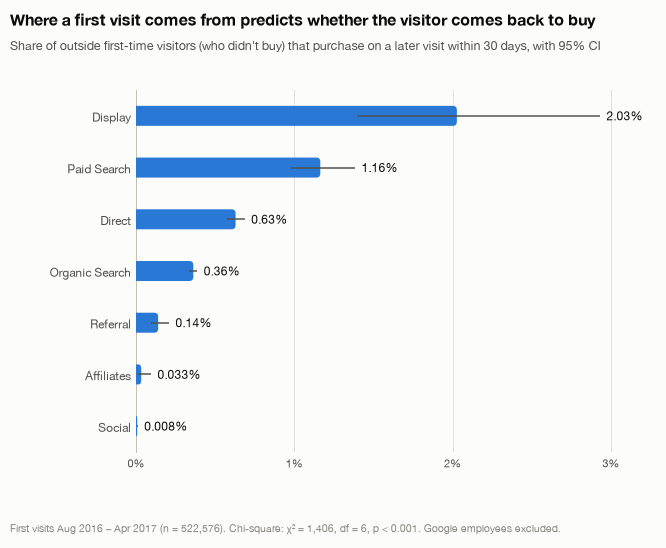

In [13]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
h1 = train[train.channel != "(Other)"]
ct = pd.crosstab(h1.channel, h1[LABEL])
chi2, p, dof, _ = chi2_contingency(ct)
g = pd.DataFrame({"n": ct.sum(axis=1), "k": ct[1]}); g["rate"] = g.k / g.n
g["lo"], g["hi"] = proportion_confint(g.k, g.n, method="wilson"); g = g.sort_values("rate", ascending=False)
rate_with_ci_chart(list(g.index), g.rate.tolist(), g.lo.tolist(), g.hi.tolist(),
    title="Where a first visit comes from predicts whether the visitor comes back to buy",
    subtitle="Share of outside first-time visitors (who didn't buy) that purchase on a later visit within 30 days, with 95% CI",
    note=f"First visits Aug 2016 – Apr 2017 (n = {g.n.sum():,}). Chi-square: χ² = {chi2:,.0f}, df = {dof}, p < 0.001. Google employees excluded.");

**The model:** I use gradient boosting with the settings that won time-based tuning in the repository (28 configurations; learning rate 0.02, 4-leaf trees, minimum leaf size 1,000), and compare it with two rules that need no model (the funnel rule, and a **two-line rule**: North American first visits first, then the funnel rule) and with the feature set of Google's own lab, refit on this corrected data.

In [14]:
scores = {"Funnel rule": funnel_rule_score(test),
          "Two-line rule": funnel_geo_rule_score(test),
          "Lab's features, refit": lab_features_pipeline().fit(train, train[LABEL]).predict_proba(test)[:, 1],
          "My model (gradient boosting)": boosting_pipeline(learning_rate=0.02, max_leaf_nodes=4, min_samples_leaf=1000)
                                               .fit(train, train[LABEL]).predict_proba(test)[:, 1]}
y = test[LABEL].to_numpy()
pd.DataFrame({k: ranking_metrics(y, s) for k, s in scores.items()}).T.style.format(
    {"pr_auc": "{:.3f}", "roc_auc": "{:.3f}", "precision_top_1pct": "{:.1%}", "lift_top_1pct": "{:.1f}x",
     "lift_top_5pct": "{:.1f}x", "lift_top_10pct": "{:.1f}x", "recall_top_10pct": "{:.1%}"})

,pr_auc,roc_auc,precision_top_1pct,lift_top_1pct,lift_top_5pct,lift_top_10pct,recall_top_10pct
Funnel rule,0.028,0.806,4.3%,12.1x,8.4x,5.4x,53.9%
Two-line rule,0.049,0.880,7.4%,21.1x,9.5x,6.1x,61.3%
"Lab's features, refit",0.055,0.901,8.3%,23.5x,10.6x,6.5x,65.0%
My model (gradient boosting),0.062,0.902,9.6%,27.3x,11.0x,6.8x,67.8%


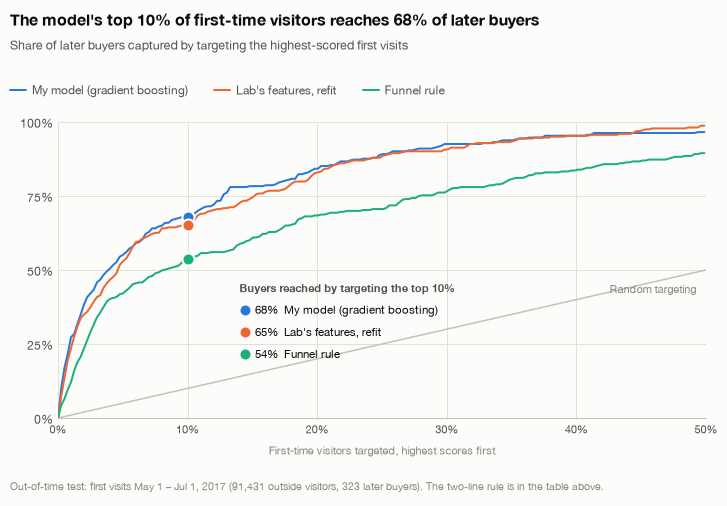

In [15]:
colors = {"My model (gradient boosting)": SERIES_1, "Lab's features, refit": "#eb6834", "Funnel rule": "#1baf7a"}
reach = top_share_recall(y, scores["My model (gradient boosting)"], 0.10)
gains_chart({k: cumulative_gains(y, scores[k]) for k in colors}, colors,
    title=f"The model's top 10% of first-time visitors reaches {reach:.0%} of later buyers",
    subtitle="Share of later buyers captured by targeting the highest-scored first visits",
    note=f"Out-of-time test: first visits May 1 – Jul 1, 2017 ({len(test):,} outside visitors, {int(y.sum())} later buyers). "
         "The two-line rule is in the table above.");

The model clearly beats the funnel rule, but a two-line rule gets most of the way (`recall_top_10pct` in the table): what the model mainly adds is a sharper top of the ranking. One caveat my red-team review caught: this population leaves out employees using the whole year of visits, which is hindsight a live campaign doesn't have. Refit and scored without it in the repository (employees whom only a later visit reveals stay in training), the model's top 10% holds 71% of real later buyers against 61% for the two-line rule, and those employees are 23% of the buyers it reaches.

**Break-even:** is a visitor worth retargeting? Only if revenue per visitor over the next 30 days × incremental lift × gross margin is at least the cost per visitor the ads actually reach. I measure revenue per visitor on the test months, take a 10% lift anchored on randomized experiments (8–10.5%) that measured it on people who actually saw an ad, and assume a 50% margin.

In [16]:
model_score = scores["My model (gradient boosting)"]
bands = value_by_band(y, test.revenue_30d_usd.to_numpy(), model_score)
bands["max_affordable_cost_usd"] = max_affordable_cost(bands.revenue_per_visitor)
bands.style.format({"buy_rate": "{:.2%}", "revenue_per_visitor": "${:.2f}", "rpv_ci_low": "${:.2f}",
                    "rpv_ci_high": "${:.2f}", "max_affordable_cost_usd": "${:.3f}"})

,band,visitors,buyers,buy_rate,revenue_per_visitor,rpv_ci_low,rpv_ci_high,max_affordable_cost_usd
0,Top 1%,914,88,9.63%,$12.25,$7.89,$17.16,$0.613
1,1%–2%,915,36,3.93%,$4.22,$2.27,$6.87,$0.211
2,2%–5%,2743,54,1.97%,$2.37,$1.21,$4.01,$0.118
3,5%–10%,4571,41,0.90%,$1.46,$0.65,$2.46,$0.073
4,10%–20%,9143,53,0.58%,$1.01,$0.47,$1.70,$0.050
5,20%–50%,27430,40,0.15%,$0.22,$0.08,$0.40,$0.011
6,50%–100%,45715,11,0.02%,$0.01,$0.01,$0.02,$0.001


In [17]:
# Extra gross profit per month, before ad costs, from retargeting the top X% (central case, 95% CI, range across lift x margin)
months = months_spanned(test.session_date)   # May 1 – Jul 1, 2017: 62 days, both ends included
value_of_targets(y, test.revenue_30d_usd.to_numpy(), model_score, months).style.format(
    {"visitors_per_month": "{:,.0f}", "share_of_later_buyers": "{:.0%}", "revenue_per_visitor": "${:.2f}",
     "gross_profit_per_month": "${:,.0f}", "ci_low": "${:,.0f}", "ci_high": "${:,.0f}", "range_low": "${:,.0f}",
     "range_high": "${:,.0f}"})

,target,visitors_per_month,share_of_later_buyers,revenue_per_visitor,gross_profit_per_month,ci_low,ci_high,range_low,range_high
0,top 1%,448,27%,$12.25,$275,$177,$385,$82,$769
1,top 5%,"2,242",55%,$4.71,$528,$395,$688,$158,"$1,479"
2,top 10%,"4,483",68%,$3.09,$692,$519,$884,$207,"$1,936"
3,top 20%,"8,966",84%,$2.05,$918,$715,"$1,158",$275,"$2,570"


The top 10% (about 4,500 visitors a month) is worth up to about USD 690 a month in the central case (USD 744 in the repository once employees in the audience are valued at zero), and the top 20% up to about USD 920. These are upper bounds: extra gross profit before ad costs, if the ads reach everyone in the audience. So retargeting is a small, cheap program. Its real lift needs a randomized test: I sized it in the repository as a 50/50 holdout of the top 20% for 12 months, which detects a lift of about 14% or more.

## 4. D1: which channels deserve the credit?

GA's report uses **last non-direct click**: when someone comes back by bookmark, GA credits their earlier campaign. I rebuild the journeys instead, following the channel each visit **actually arrived through**, with employees and the key account left out. Purchases are credited under five path-based rules, GA's own among them, and a **third-order Markov chain** (the order was chosen by held-out likelihood in the repository). Revenue is capped per purchase session at the cap set in the repository's Process phase (USD 1,606), and the bootstrap resamples visitors.

In [18]:
t = touches(sessions)                      # outside visitors, key account excluded
cap = revenue_cap(sessions)                # $1,606 per purchase session
j = journeys(t, revenue_cap_usd=cap)
att = Attribution(j, "arrival_path", order=3)
shares = att.shares()
boot = att.bootstrap_shares(n_boot=N_BOOT, seed=42, clusters=j.full_visitor_id)   # resamples visitors
order = ["Organic Search", "Direct", "Paid Search", "Referral", "Display", "Social", "Affiliates"]
print(f"{int(j.converted.sum()):,} purchases; revenue cap ${cap:,.2f} per purchase session")
shares.loc[order].style.format("{:.1%}")

5,058 purchases; revenue cap $1,605.91 per purchase session


model,ga_last_click,last_touch,first_touch,linear,position_based,markov
Organic Search,53.8%,30.0%,44.9%,35.8%,36.7%,38.2%
Direct,32.6%,60.9%,43.9%,54.2%,53.2%,49.3%
Paid Search,7.5%,5.6%,7.3%,6.4%,6.4%,6.7%
Referral,3.0%,1.4%,1.2%,1.3%,1.3%,2.2%
Display,1.6%,1.0%,1.4%,1.2%,1.2%,1.4%
Social,1.5%,1.0%,1.2%,1.1%,1.1%,1.8%
Affiliates,0.1%,0.0%,0.1%,0.0%,0.0%,0.3%


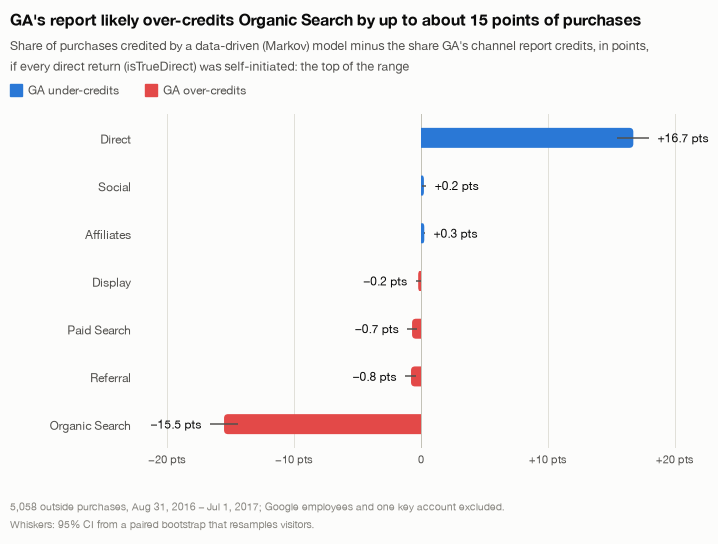

In [19]:
gi, mi = MODELS.index("ga_last_click"), MODELS.index("markov")
idx = {c: i for i, c in enumerate(att.channels)}
chart_order = ["Direct", "Social", "Affiliates", "Display", "Paid Search", "Referral", "Organic Search"]
vals, lo, hi = [], [], []
for c in chart_order:
    d = 100 * (boot[:, idx[c], mi] - boot[:, idx[c], gi])
    vals.append(100 * (shares.loc[c, "markov"] - shares.loc[c, "ga_last_click"]))
    lo.append(np.percentile(d, 2.5)); hi.append(np.percentile(d, 97.5))
diverging_ci_chart(chart_order, vals, lo, hi,
    title="GA's report likely over-credits Organic Search by up to about 15 points of purchases",
    subtitle=("Share of purchases credited by a data-driven (Markov) model minus the share GA's channel report credits, in points,\n"
              "if every direct return (isTrueDirect) was self-initiated: the top of the range"),
    note=(f"{int(j.converted.sum()):,} outside purchases, Aug 31, 2016 – Jul 1, 2017; Google employees and one key account excluded.\n"
          "Whiskers: 95% CI from a paired bootstrap that resamples visitors."),
    pos_label="GA under-credits", neg_label="GA over-credits",
    value_fmt=lambda v: f"{v:+.1f} pts", tick_fmt=lambda t: f"{t:+.0f} pts");

The gap assumes every `isTrueDirect` visit was a self-initiated return. GA also sets that flag when two visits in a row carry the same campaign details, such as a repeat Google search, and the export can't tell the two apart. So in the repository I show the range: 15.5 points at the top, 1.8 on GA's own labels, and about 13–15 at a benchmark from how returning visitors behave. Hence **"likely up to about 15 points"**, with moderate confidence. With Direct split by visit number, visitors returning directly bring 34% of purchases; when they first came from a campaign, GA's report credits that campaign.

**What is a paid click worth?** Capped revenue each rule credits to a channel, divided by the visits it actually brought (ad clicks). The seventh rule, a conservative relabel, is the repository's last one.

In [20]:
clicks = t.arrival_channel.value_counts()
revenue = att.credit_table().xs("revenue", axis=1, level="measure")[MODELS].copy()
revenue["markov_conservative"] = Attribution(j, "conservative_path", order=3).credit_table()[("markov", "revenue")]
per_click = revenue.loc[["Paid Search", "Display"]].div(clicks.loc[["Paid Search", "Display"]], axis=0).T
per_click["Paid Search bid cap, 50% margin"] = per_click["Paid Search"] * 0.5
per_click.style.format("${:.2f}")

,Paid Search,Display,"Paid Search bid cap, 50% margin"
model,,,
ga_last_click,$2.21,$3.87,$1.11
last_touch,$1.56,$2.89,$0.78
first_touch,$2.08,$2.96,$1.04
linear,$1.78,$2.84,$0.89
position_based,$1.81,$2.90,$0.90
markov,$2.01,$3.28,$1.00
markov_conservative,$2.43,$3.80,$1.21


**Paid Search:** a click is credited with **USD 1.56–2.43** under the seven rules, so at a 50% margin the break-even bid is at most **USD 0.78–1.21**, and only if every attributed sale needed the ad. In the repository, all 65 Paid Search purchases with a readable keyword were on brand keywords (the store's or Google's name), the clicks least likely to need an ad, so I'd split brand from non-brand and test brand bidding before raising bids.

**Display:** without the key account, a click is credited with **USD 2.84–3.87** under every rule (GA's report put it at USD 9.08 with the account, as the repository's notebook 05 shows). The value is stable, but it's attribution, not incrementality. A purchase-based holdout can't detect Display's effect at about 2 credited purchases a week, so I recommend a 12-week 50/50 holdout of Display's own audience, measured on site visits (it has enough power only if that audience makes at most about 500–1,000 visits a week).

## 5. Audit of Google's teaching lab (summary)

Google's lab *Predict Visitor Purchases with a Classification Model in BigQuery ML* (GSP229) teaches BigQuery ML with the label `will_buy_on_return_visit`, and reports ROC-AUC 0.91. I recreated it in BigQuery ML with the lab's own SQL (0.724 / 0.909 vs the published 0.72 / 0.91) and found:
- its 0.91 is inflated: **61%** of its training positives and **74%** of its evaluation positives are Google employees, and its top 1% of prospects are **98.8% employees**;
- on outside visitors it scores **0.863** (against 0.910 on all first visits, both recomputed from the row-level predictions), close to a version trained without employees (0.877).

Fine for teaching; remove internal traffic before targeting.

## 6. What I'd do

**Now**

1. Report Google employees and the key account as their own segments.
2. Show a multi-touch view beside GA's channel report, with the Organic Search range.
3. Split brand from non-brand search, and keep bids under the value ceiling (USD 0.78–1.21 a click at most).
4. Review any spend on YouTube promotion and affiliates.

**Test**

5. Retarget only the top-scored first-time visitors, and measure the lift with a 50/50 holdout of the top 20% for 12 months.
6. Hold Display's budget and run a 12-week 50/50 holdout of Display's own audience, measured on site visits (if that audience makes at most about 500–1,000 visits a week).

**Explore**

7. Retention: email and reminders for past visitors.
8. A direct sales path for corporate (bulk) buyers.

## 7. What I learned

- **Question the data before the model.** The biggest findings came from asking who is in the data: employees and one corporate buyer changed almost every channel number.
- **Credit isn't causation.** Attribution shows the paths people took, not what each channel caused, so the recommendations end in tests.
- **Review early.** An AI-assisted red-team review changed six conclusions at the end; next time I'd review at the start and halfway too. The repository lists what changed.
- **Start from the decision.** Framing the work around the Head of Marketing's two decisions told me which analyses mattered.

*Data: Google Analytics 360 sample (`bigquery-public-data.google_analytics_sample`), published by Google.*